# Results

In [45]:
DATASET_PATH = "../dataset/bigcodebench_normalized.json"
OUT_PATH      = "../results/bigcodebench_llm_clones.json"
OLLAMA_MODEL = "llama3.1:latest"   

# Generation settings
LLM_OPTS = {
    "temperature": 0.6,
    "top_p": 0.95,
    "repeat_penalty": 1.05,
    "num_predict": 768,   
}

N_ENTRIES = 4
CLONES_PER_ENTRY = 2  

## Running tests

In [46]:
import json
from src.utils import install_package, extract_required_packages
with open(OUT_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)  # dataset with clones
packages = extract_required_packages(clone_data)
print(f"Requried packages: {packages}")
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        try:
            print(f"Installing missing package: {pkg}")
            install_package(pkg)
        except Exception as e:
            print(f"⚠️ Could not install package {pkg}, skipping. Reason: {e}")

Requried packages: {'string', 'collections', 'random', 'itertools', 'statistics', 'numpy'}



Testing Entry 1/10 | id=BigCodeBench/0
  Clone 1: 0/10 tests passed
  Clone 2: 9/10 tests passed
  Clone 3: 2/10 tests passed
  Clone 4: 2/10 tests passed
  Clone 5: 2/10 tests passed
  Clone 6: 2/10 tests passed
  Clone 7: 10/10 tests passed
  Clone 8: 10/10 tests passed
  Clone 9: 10/10 tests passed
  Clone 10: 10/10 tests passed
  Clone 11: 10/10 tests passed
Validation error: cannot import name 'permutation' from 'scipy.stats' (c:\Users\lamp6\anaconda3\Lib\site-packages\scipy\stats\__init__.py)
  Clone 12: 0/0 tests passed

Testing Entry 2/10 | id=BigCodeBench/1
  Clone 1: 3/3 tests passed
  Clone 2: 3/3 tests passed
  Clone 3: 3/3 tests passed
  Clone 4: 3/3 tests passed
  Clone 5: 3/3 tests passed
  Clone 6: 3/3 tests passed
{'O': 1, 'h': 1, 'b': 3, 'V': 3, 'r': 3, 'p': 1, 'o': 3, 'i': 1, 'g': 2, 'R': 1, 'I': 2, 'f': 3, 'L': 2, 'B': 2, 'c': 1, 'n': 2, 'G': 1, 'M': 1, 'J': 1, 'm': 1, 'T': 1, 'P': 1, 'S': 2, 'A': 1, 'C': 1, 'Z': 2, 'a': 1, 'W': 2, 'k': 1, 'v': 2, 'j': 1}
  Clone 7

C:\Users\lamp6\AppData\Local\Temp\tmp7ul8q33g.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 5))


  Clone 5: 8/8 tests passed
  Clone 6: 8/8 tests passed
  Clone 7: 8/8 tests passed
  Clone 8: 0/8 tests passed
  Clone 9: 8/8 tests passed
  Clone 10: 8/8 tests passed
  Clone 11: 0/8 tests passed
  Clone 12: 8/8 tests passed

✅ Done. Saved dataset with test results to ../results/bigcodebench_llm_clones.json


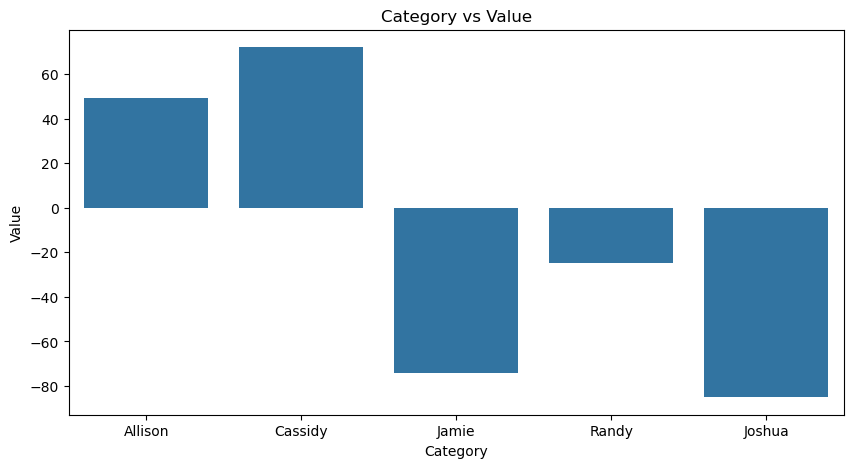

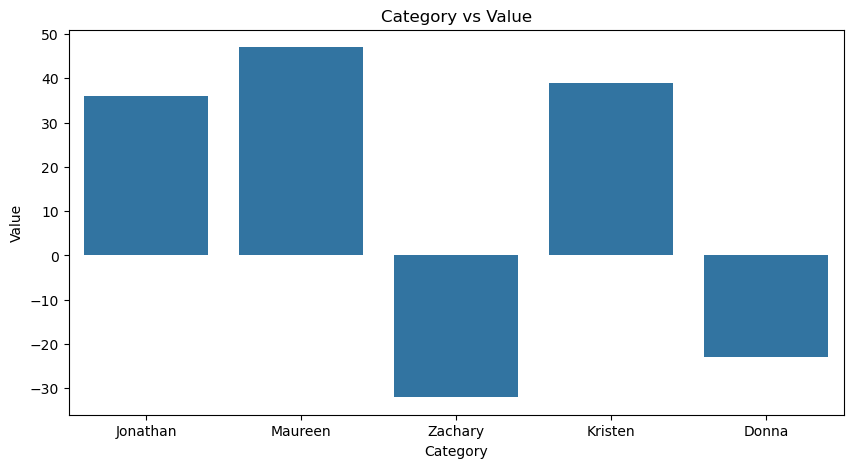

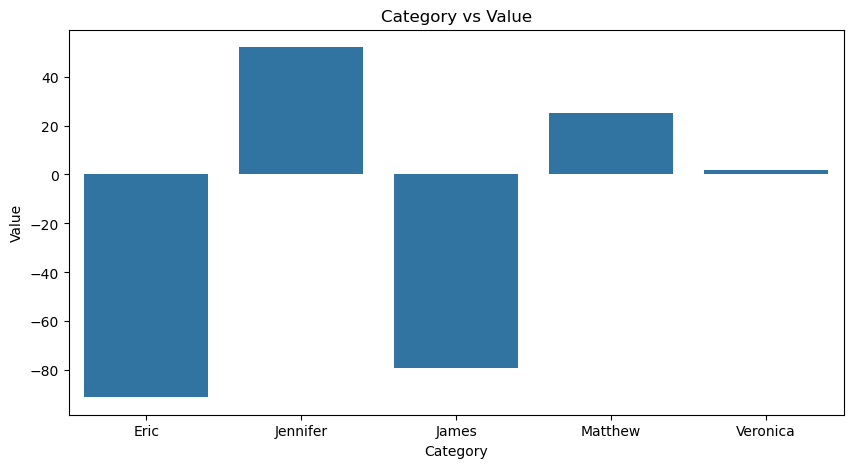

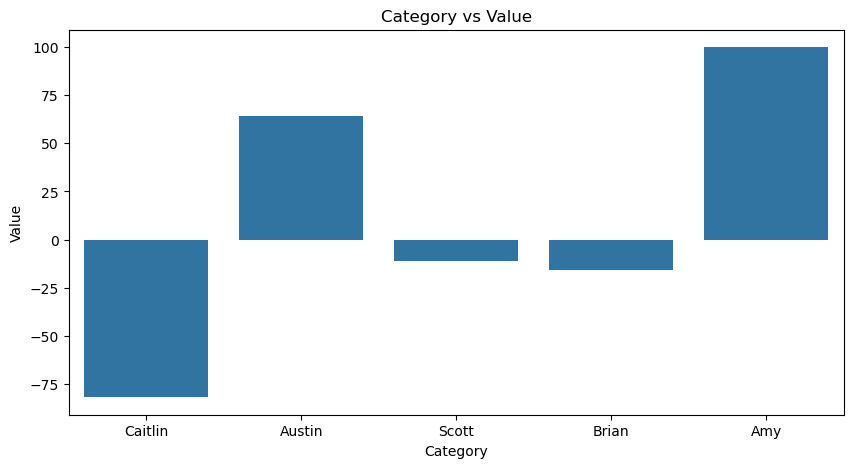

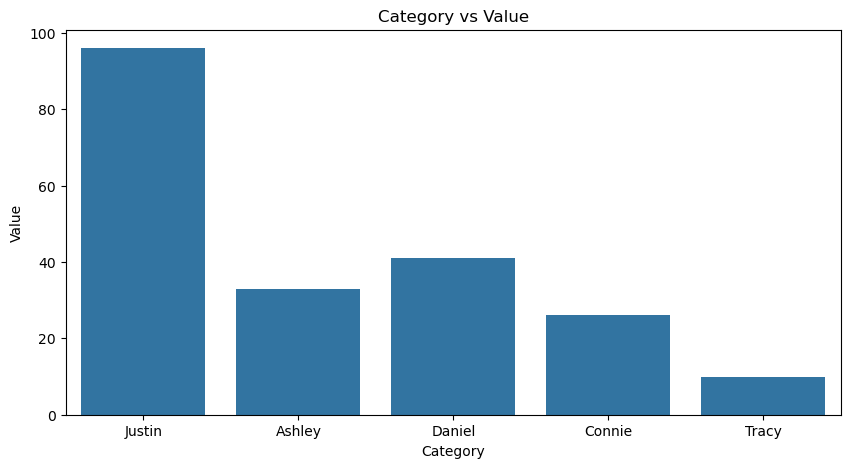

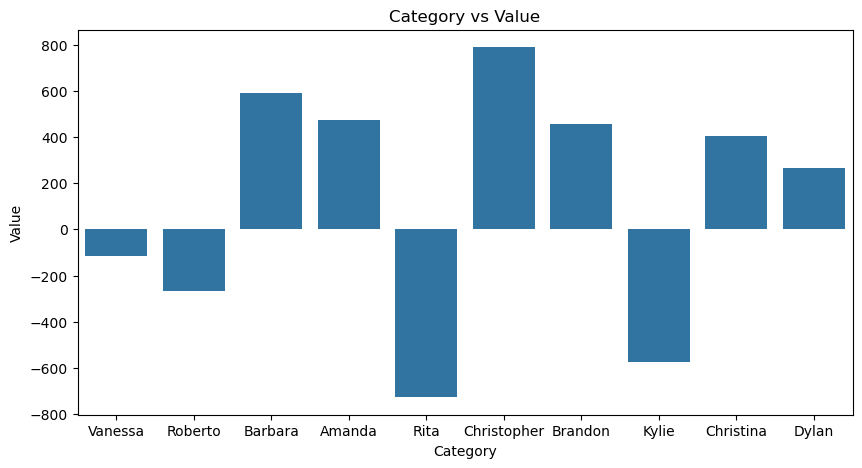

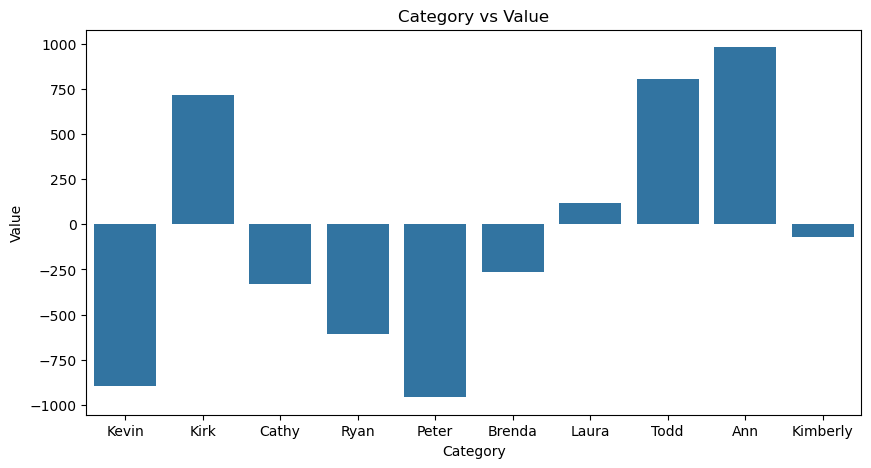

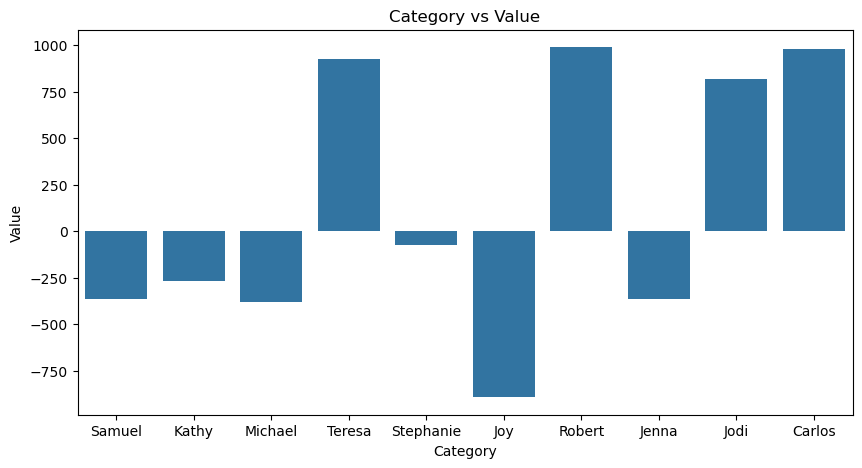

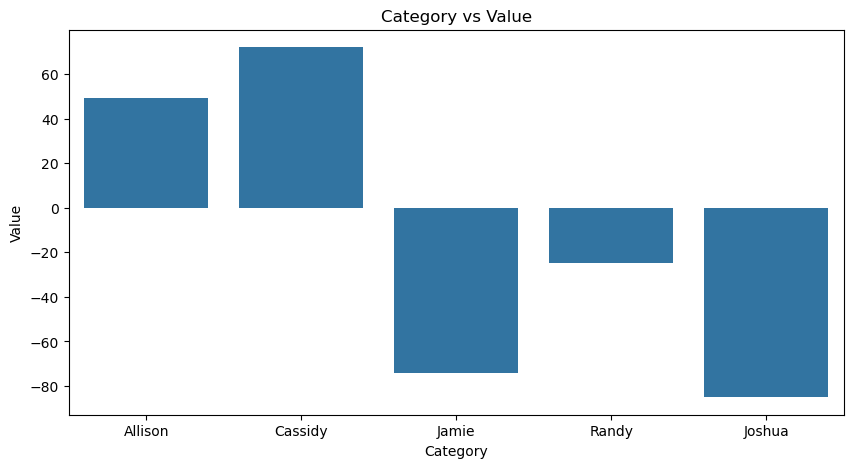

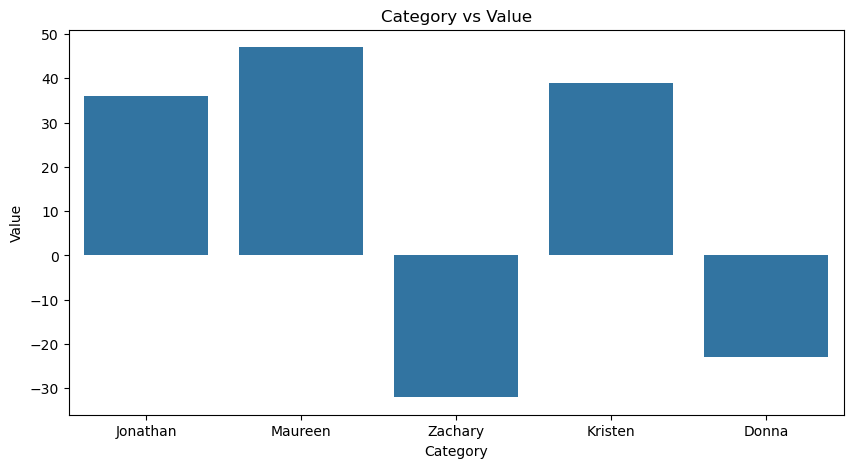

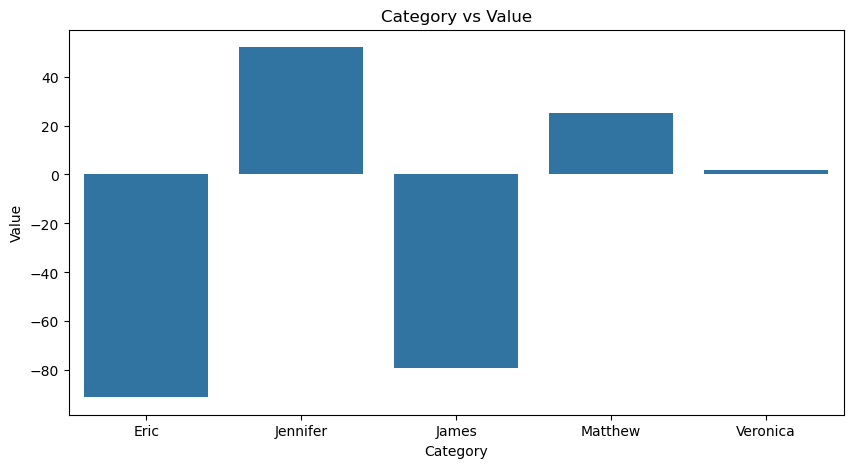

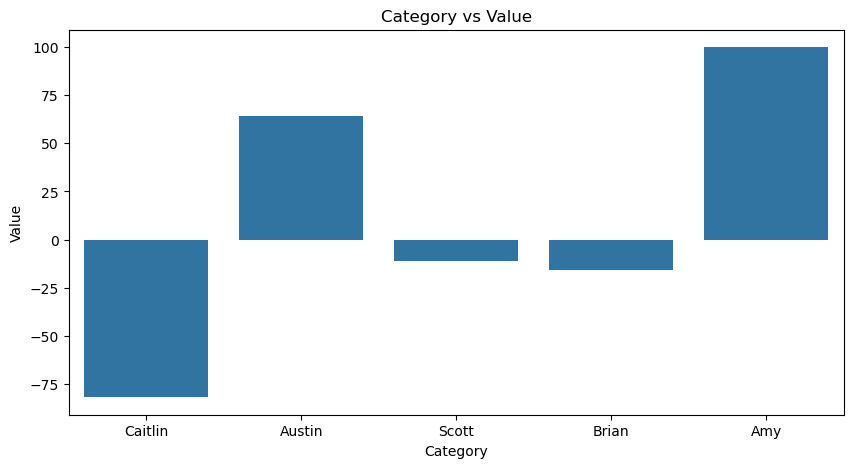

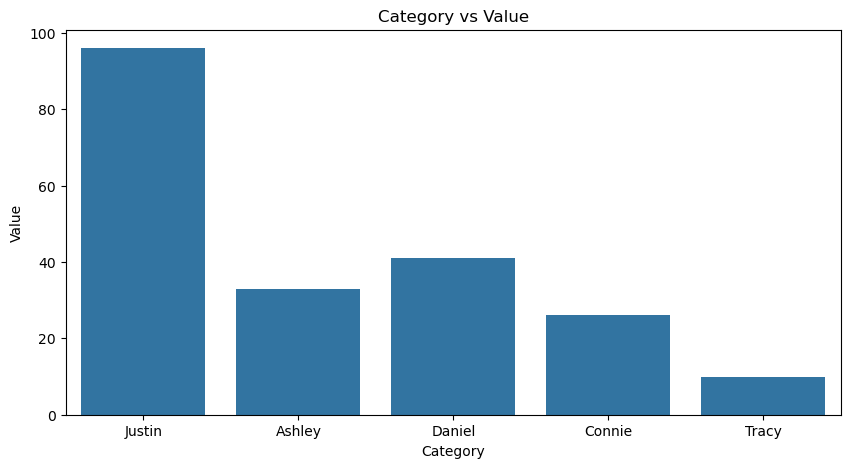

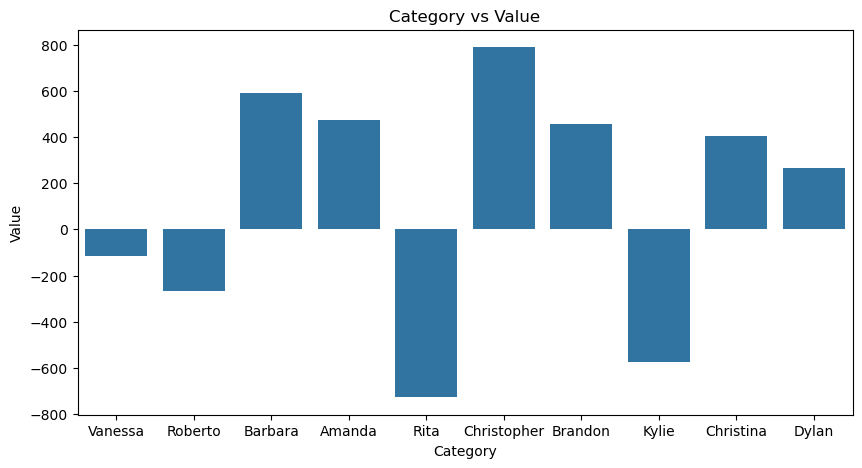

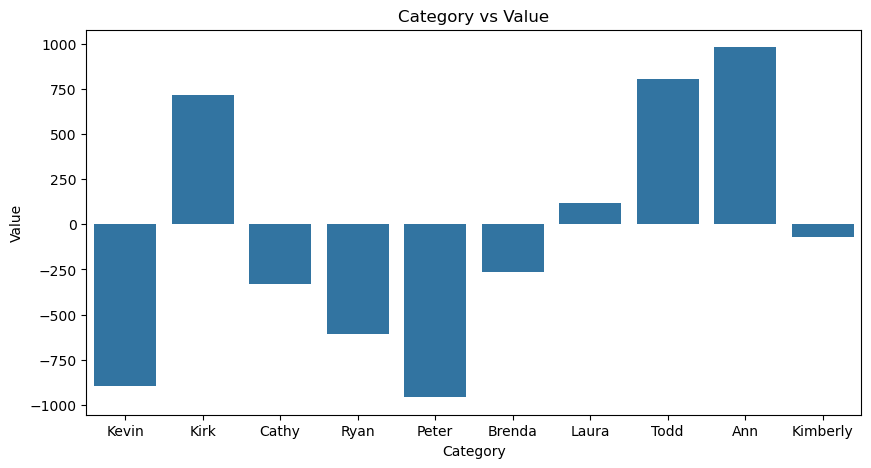

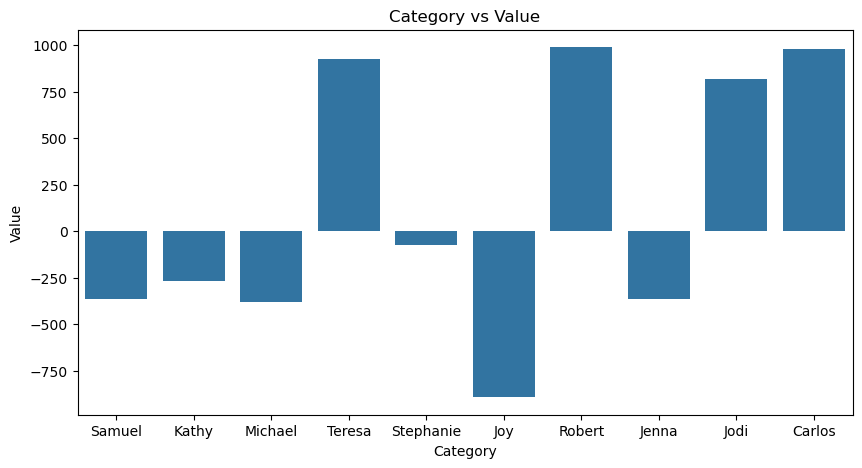

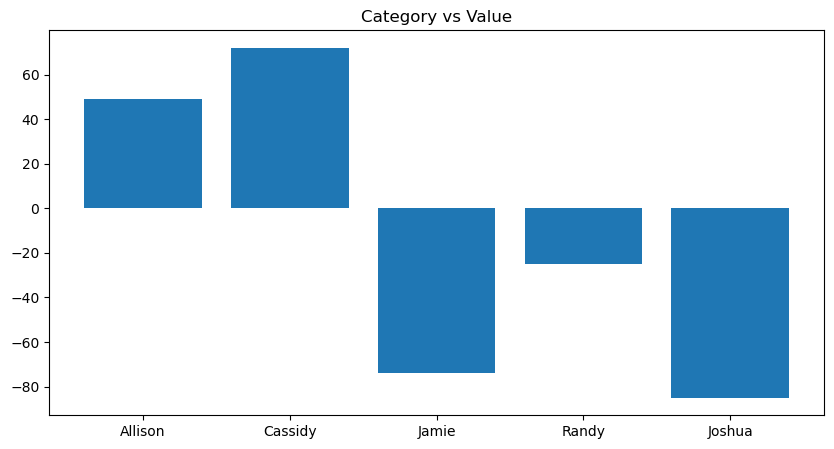

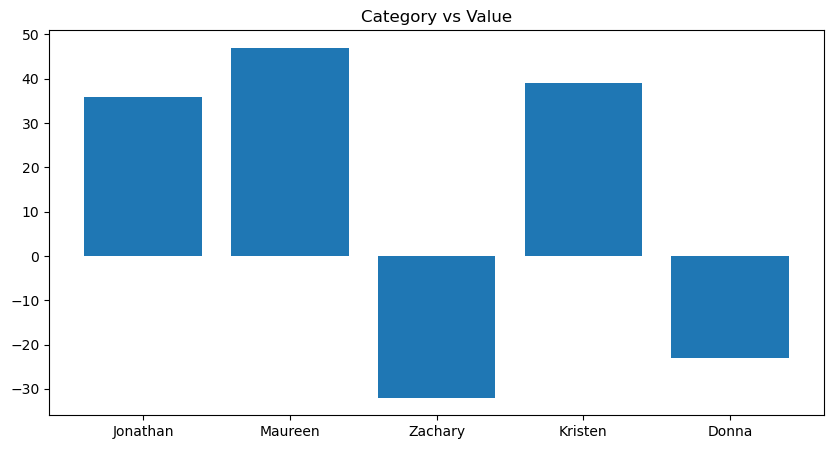

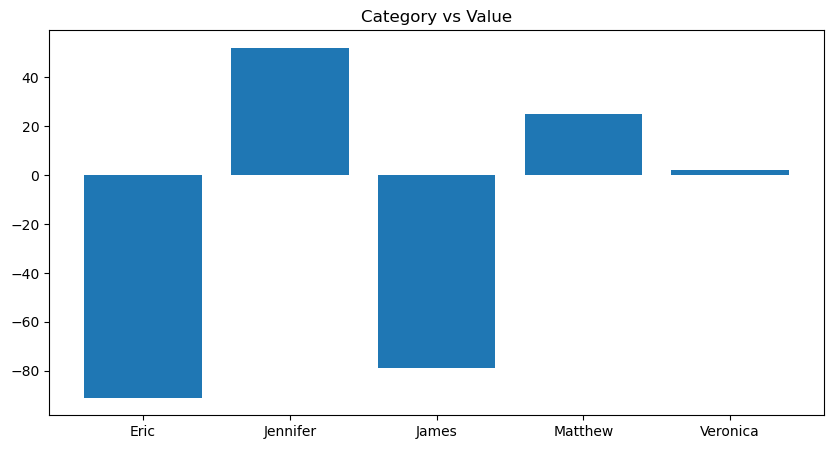

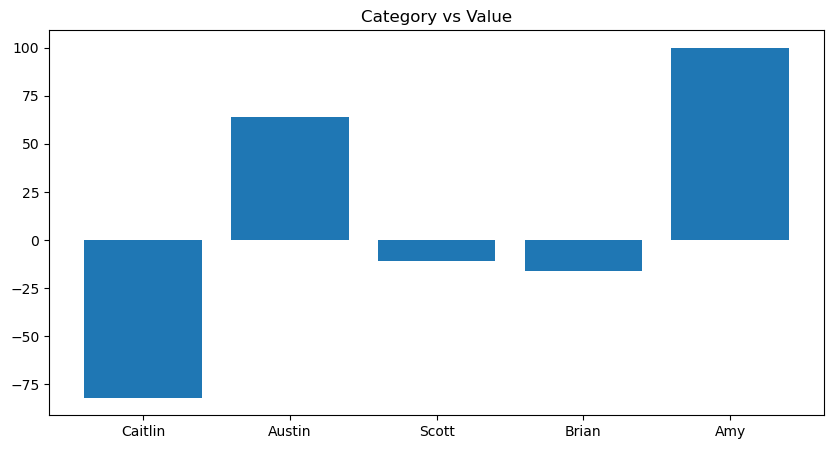

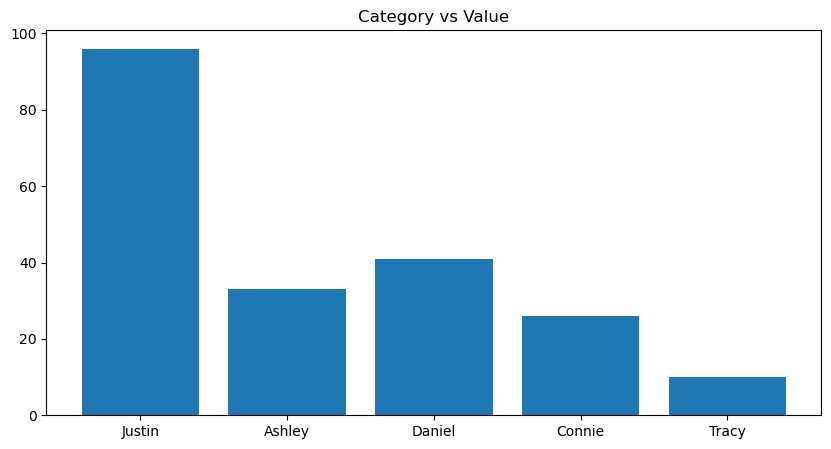

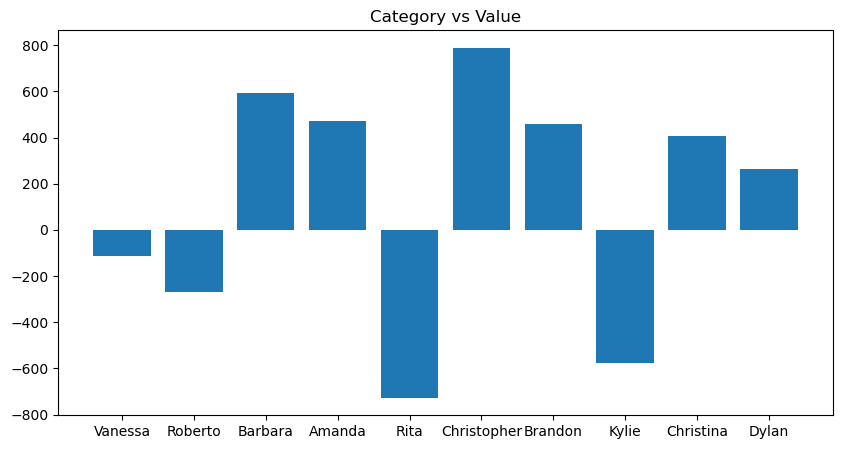

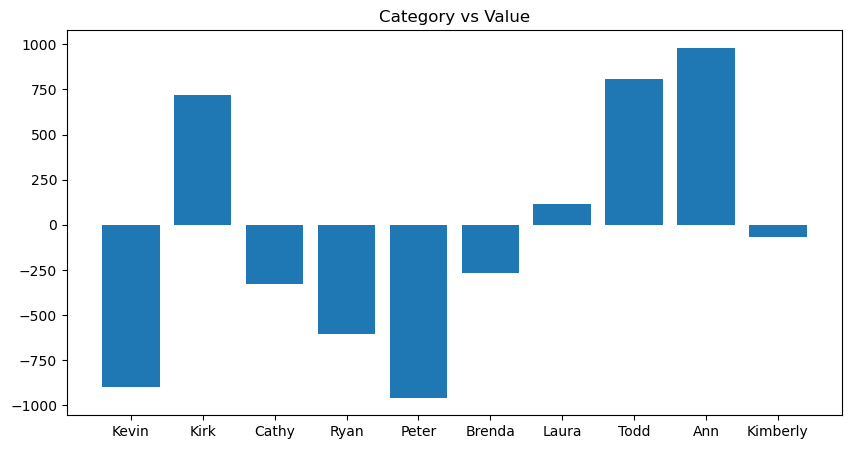

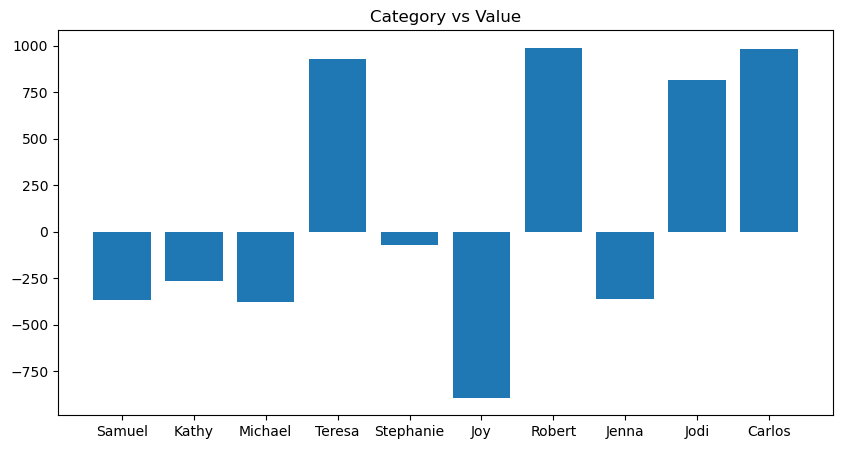

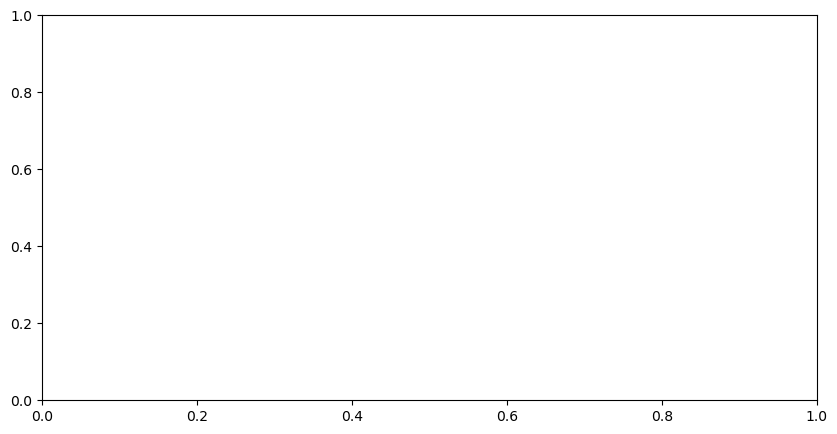

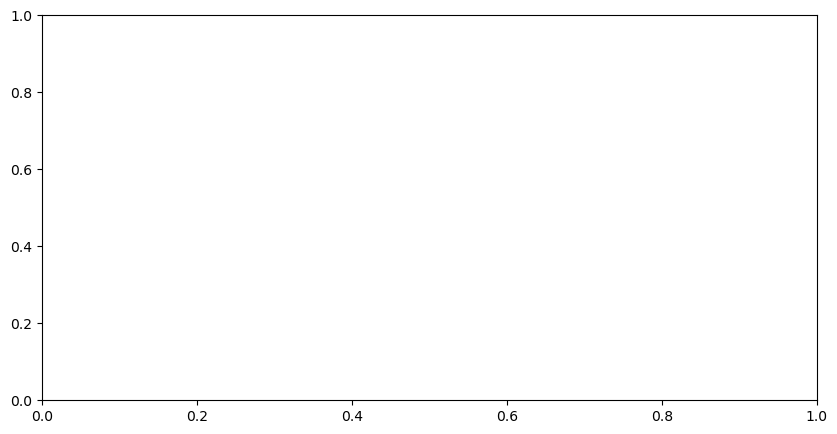

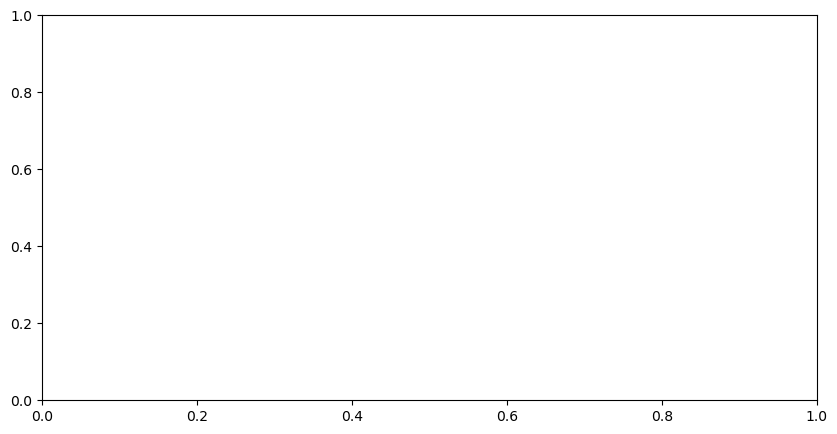

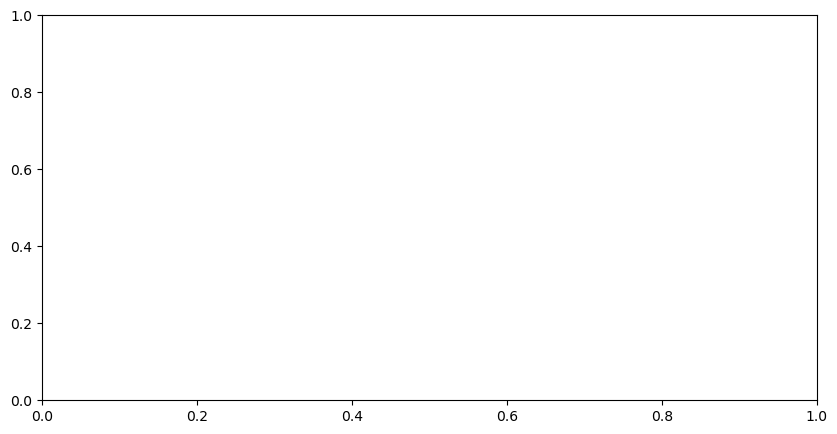

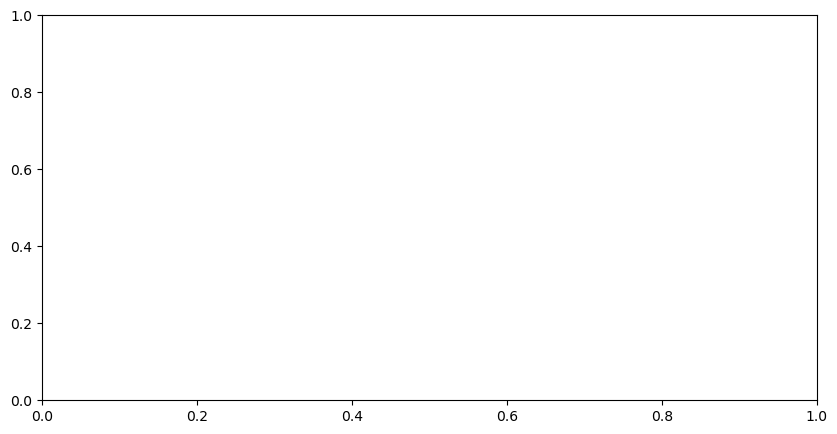

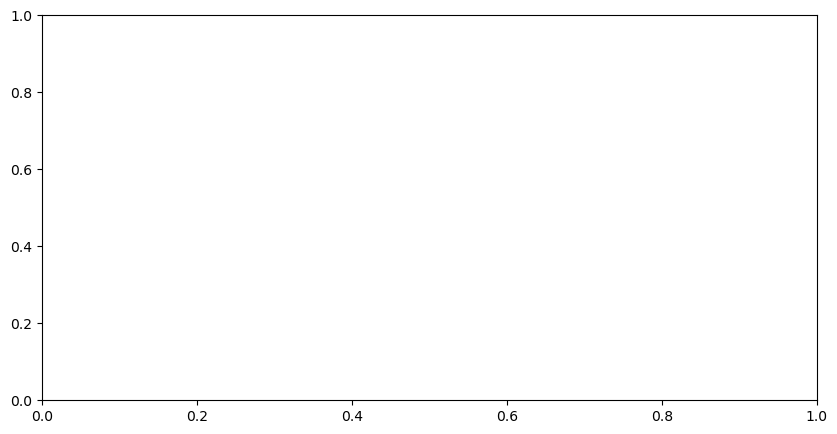

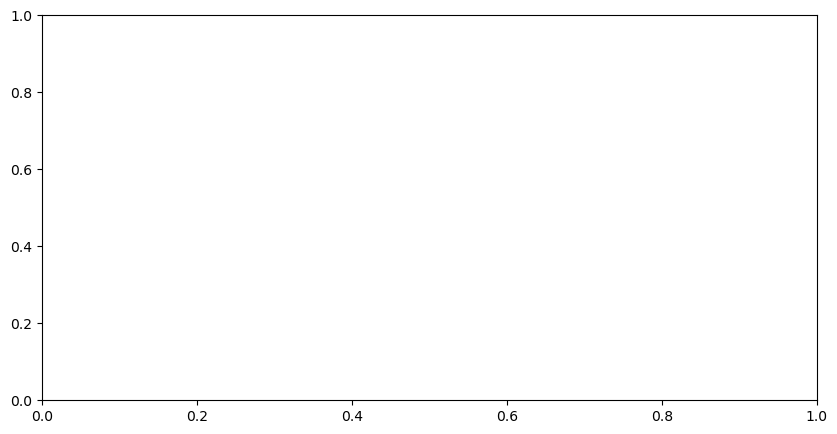

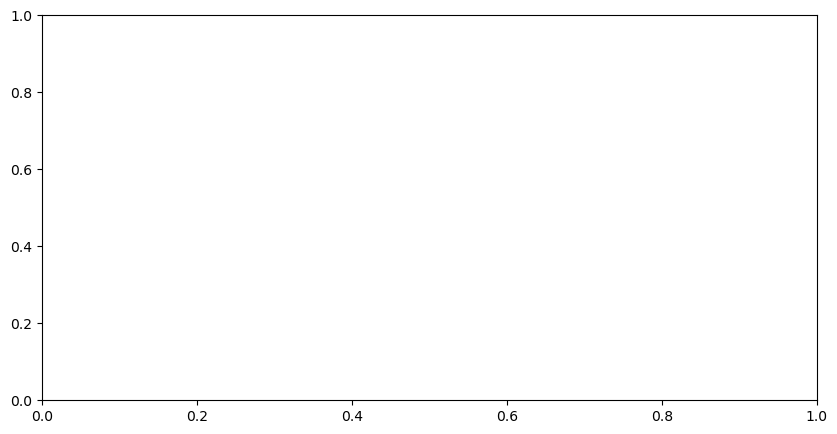

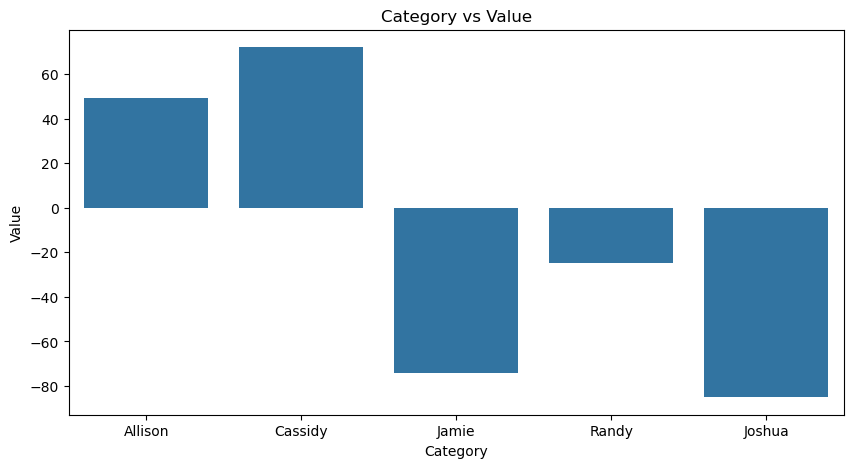

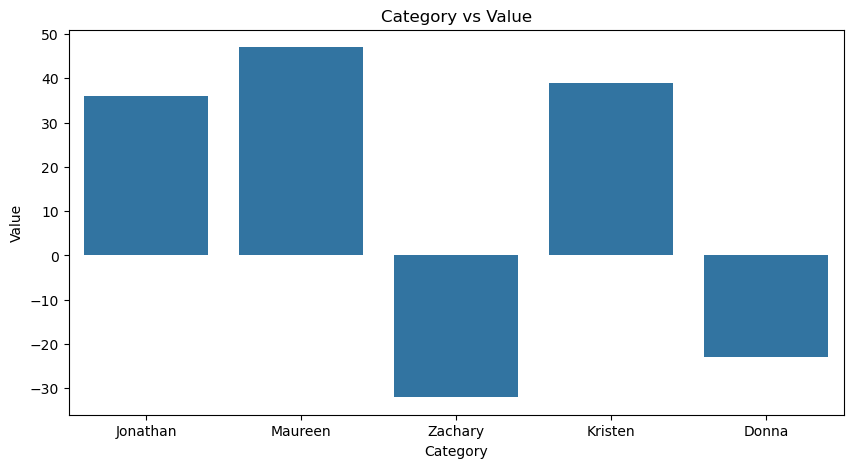

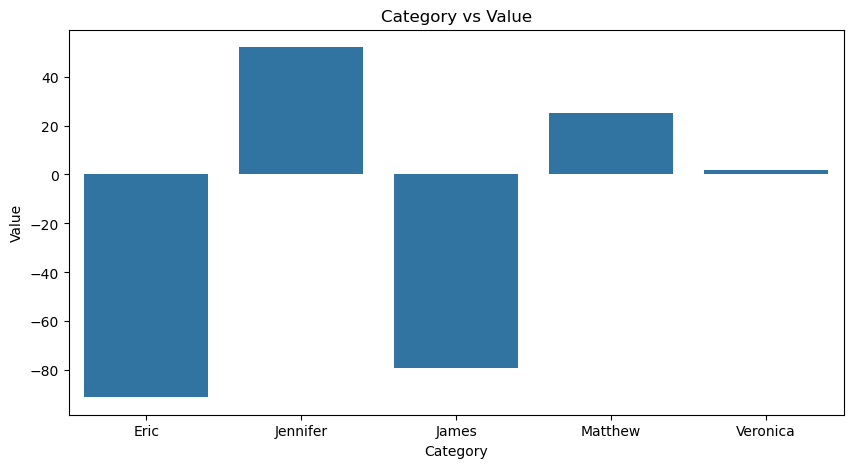

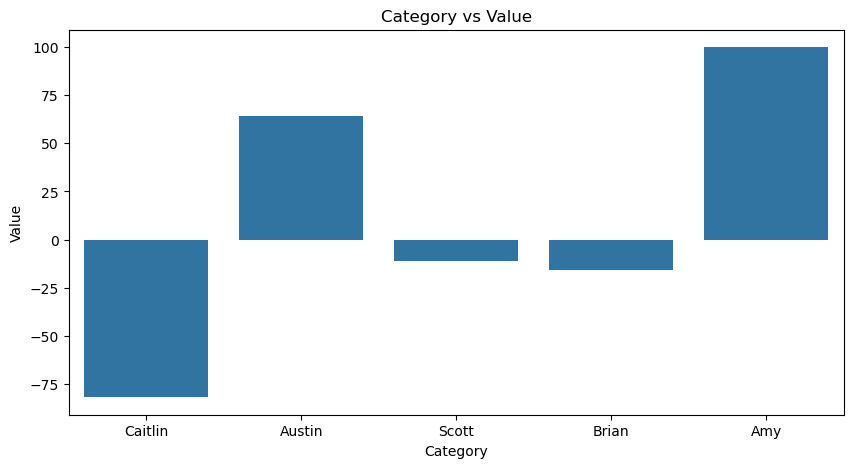

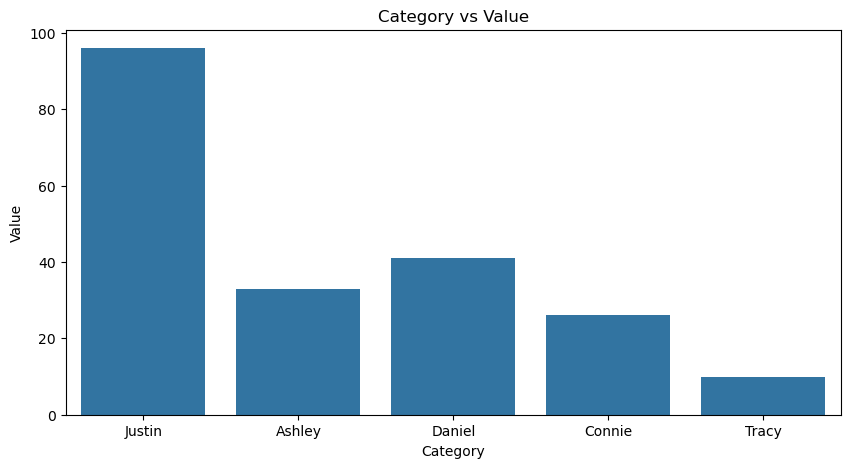

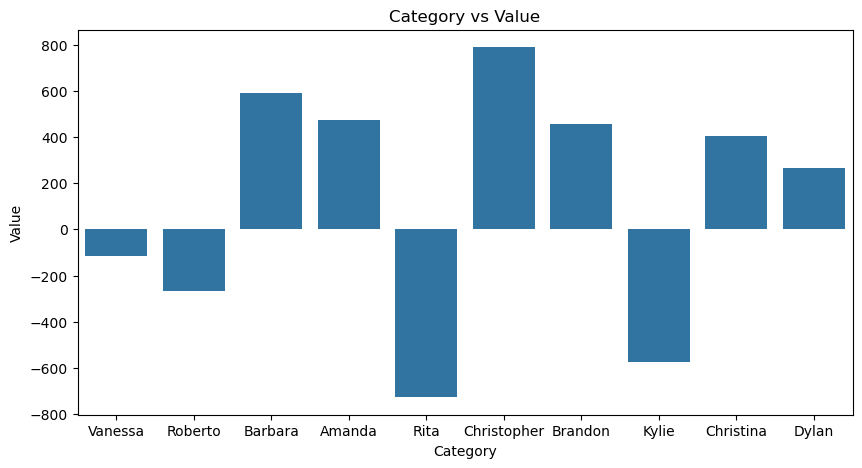

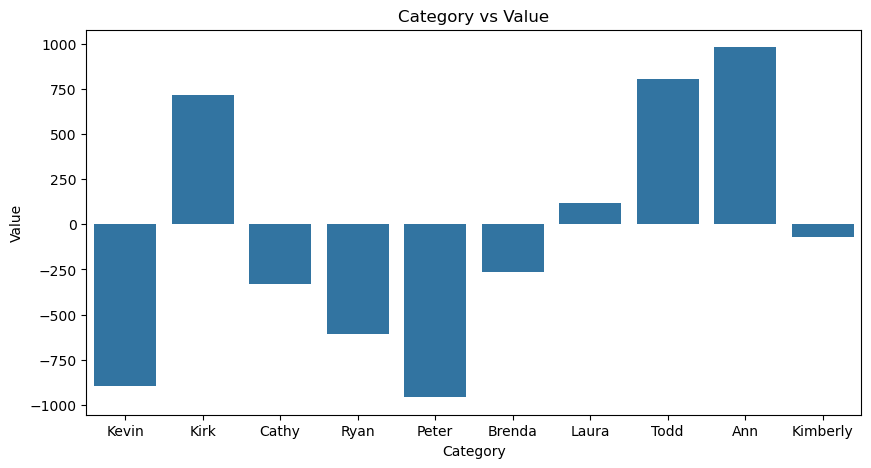

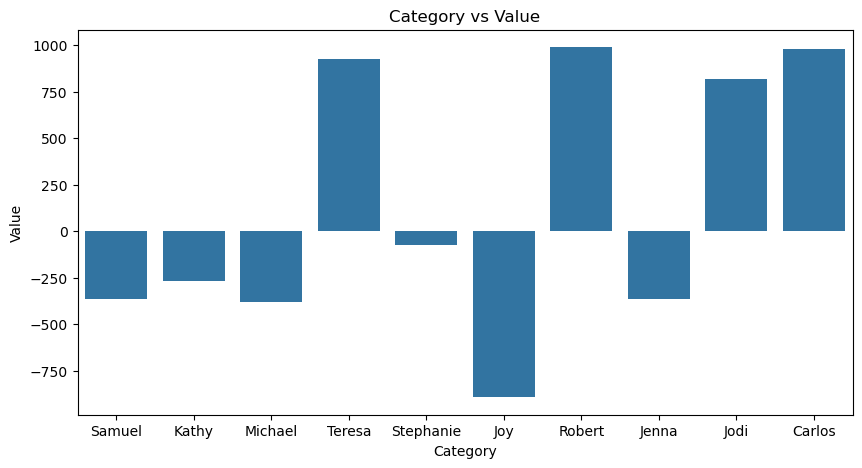

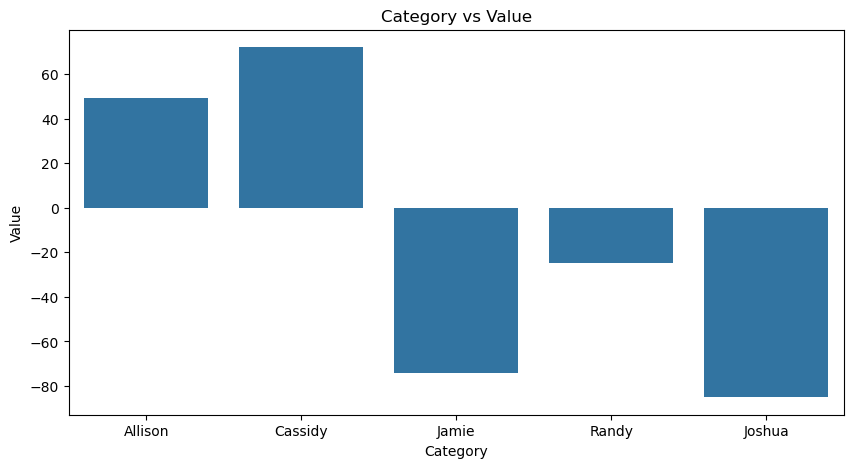

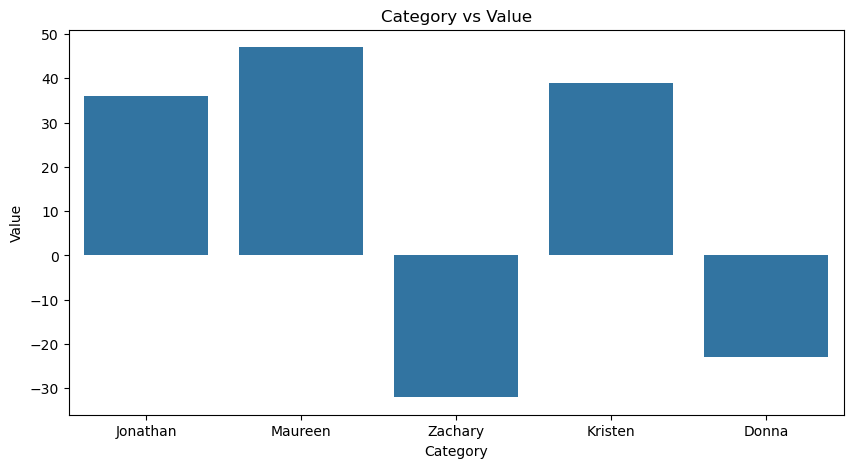

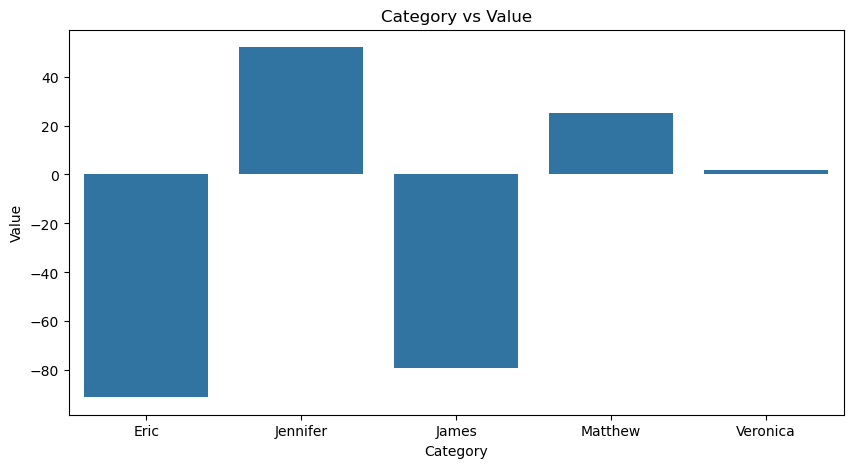

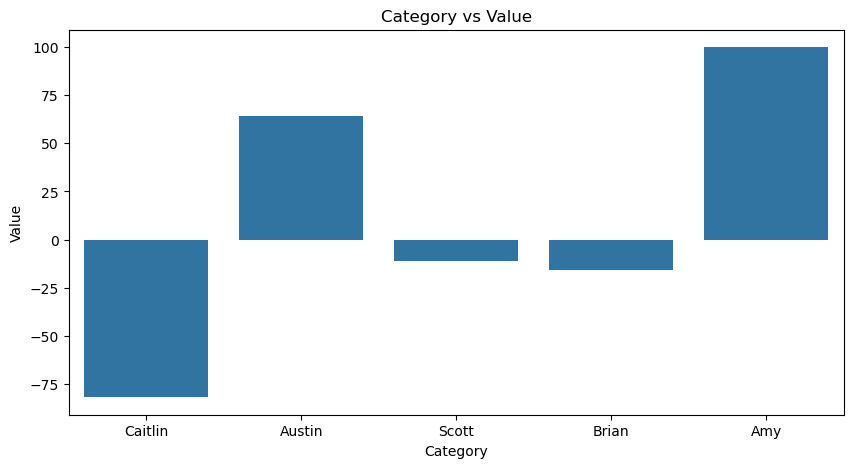

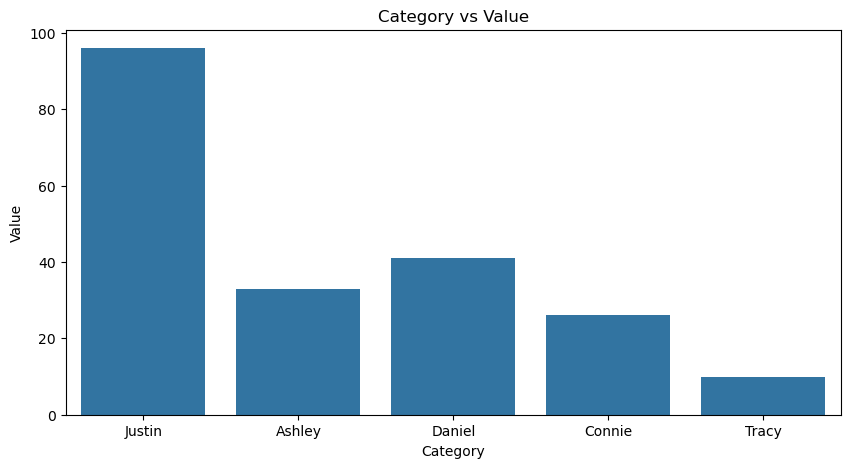

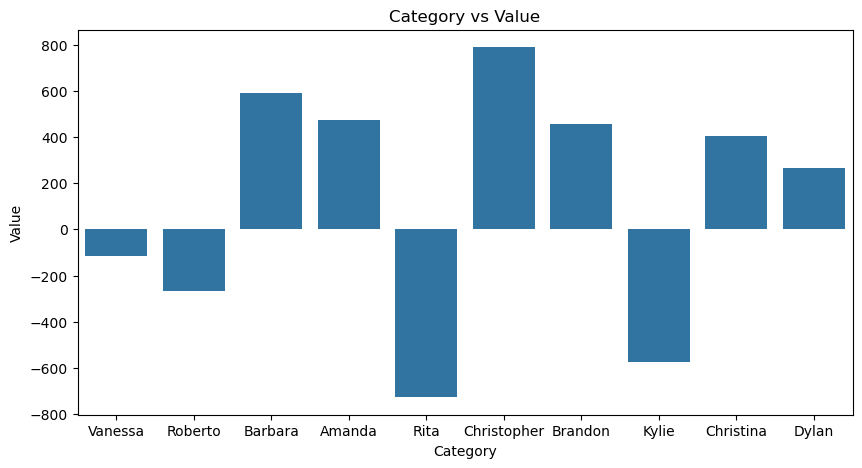

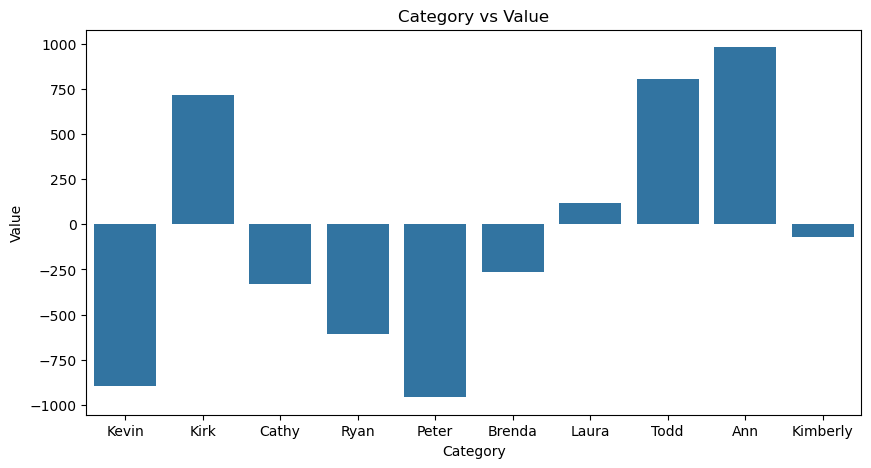

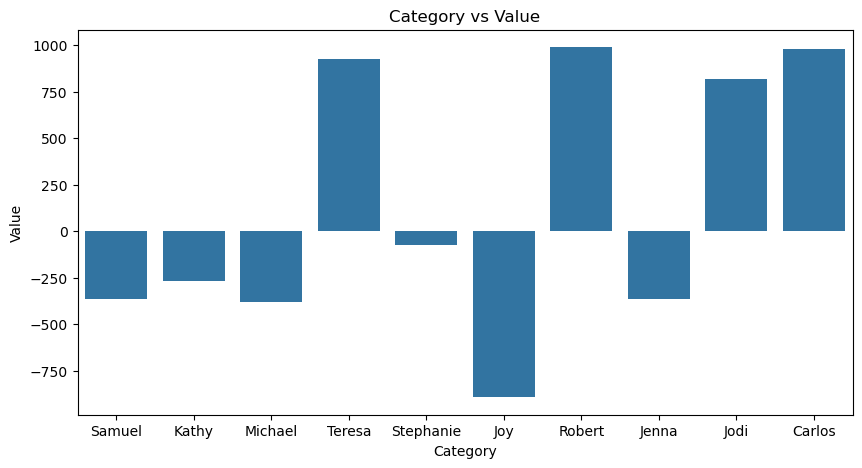

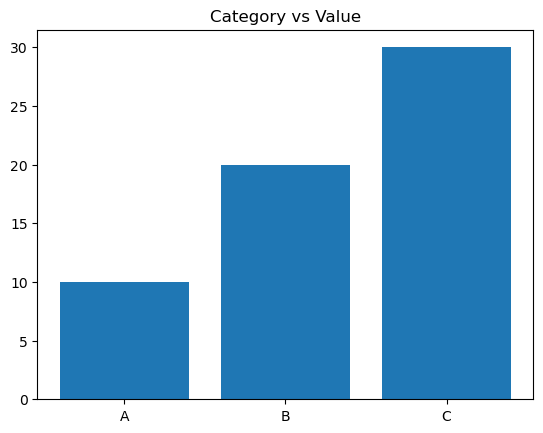

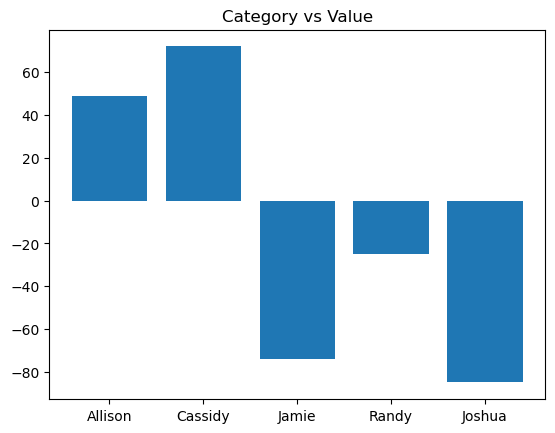

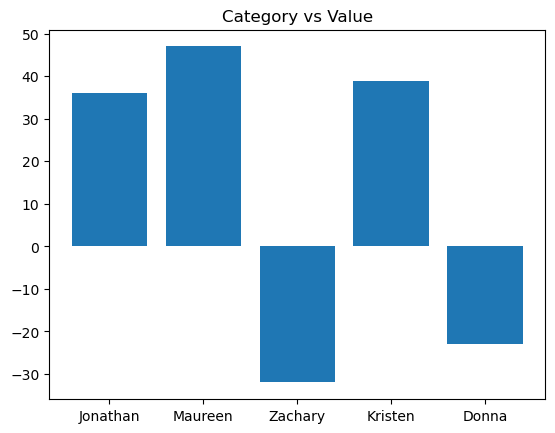

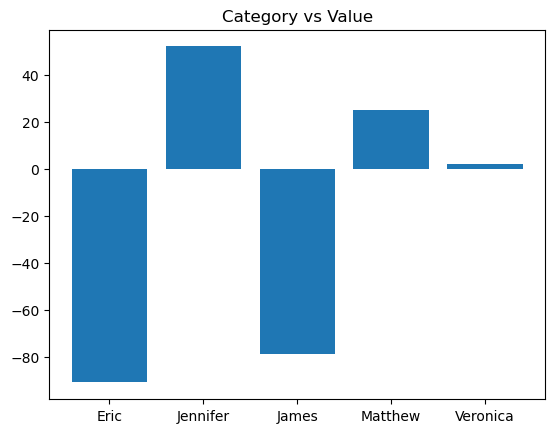

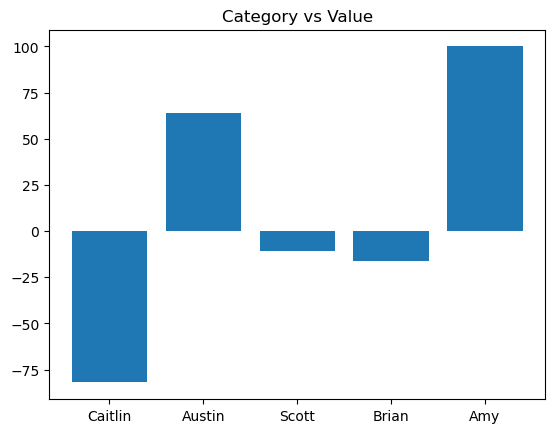

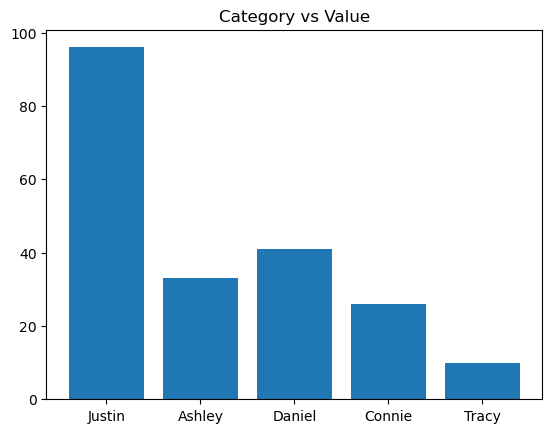

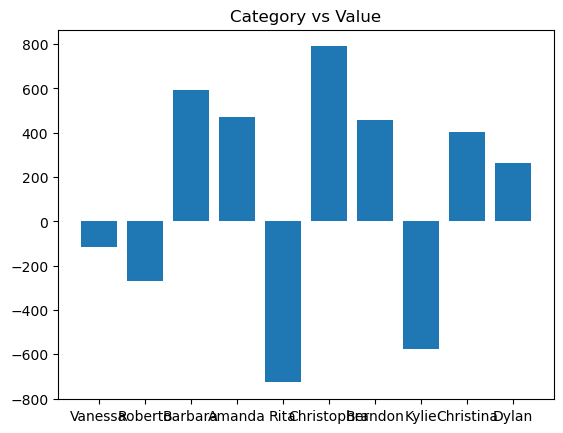

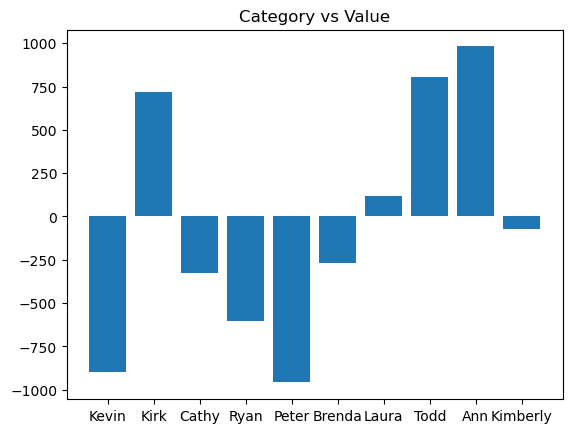

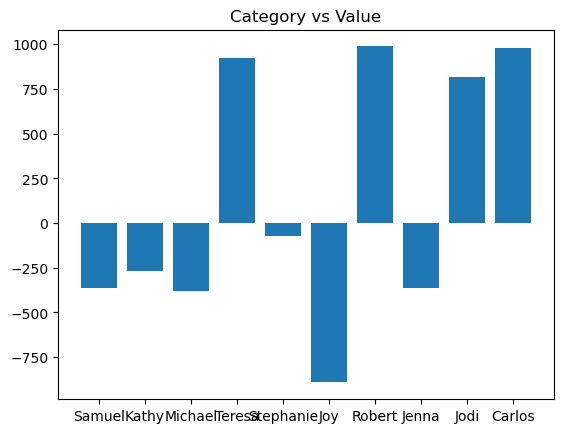

<Figure size 1000x600 with 0 Axes>

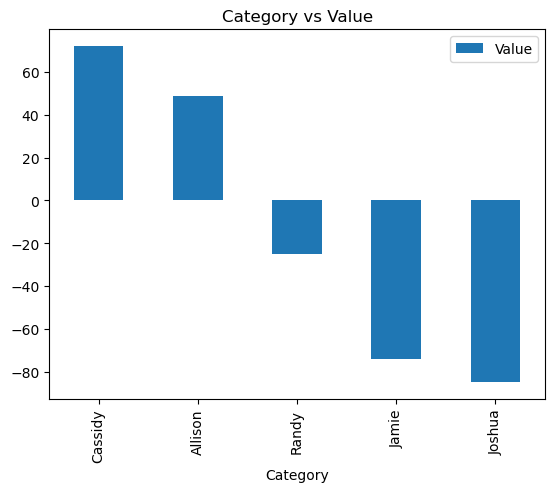

<Figure size 1000x600 with 0 Axes>

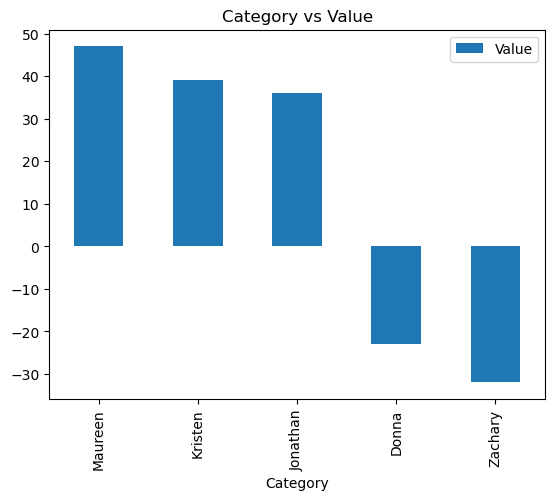

<Figure size 1000x600 with 0 Axes>

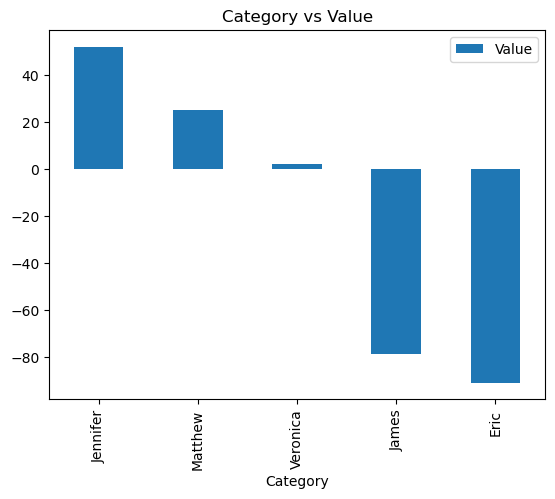

<Figure size 1000x600 with 0 Axes>

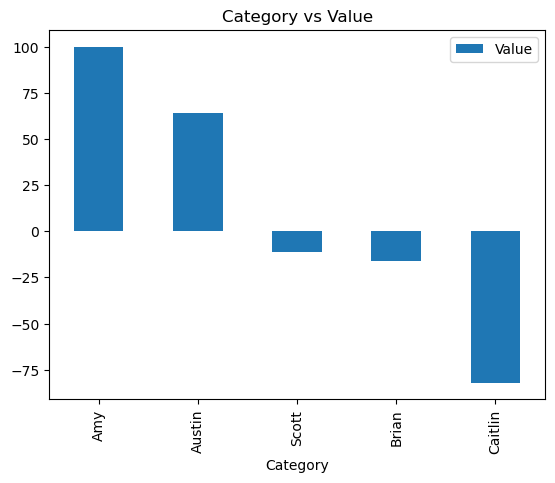

<Figure size 1000x600 with 0 Axes>

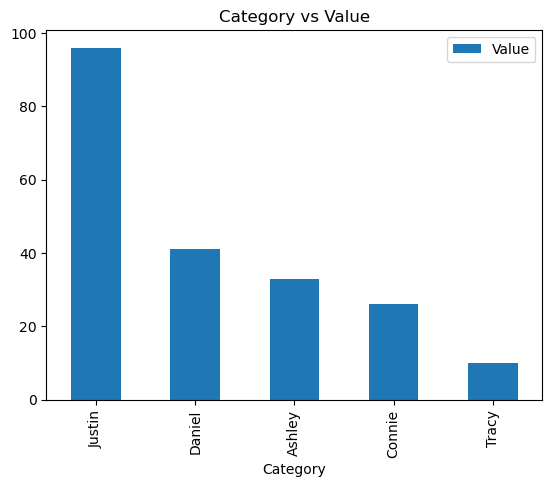

<Figure size 1000x600 with 0 Axes>

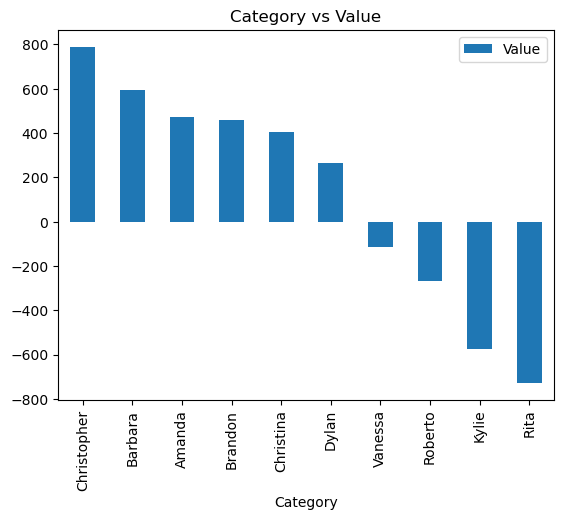

<Figure size 1000x600 with 0 Axes>

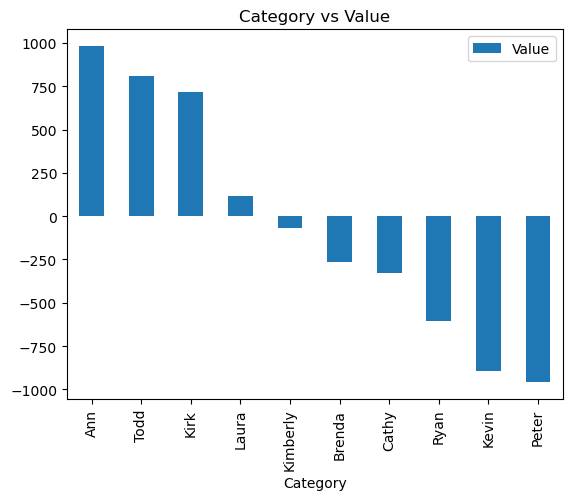

<Figure size 1000x600 with 0 Axes>

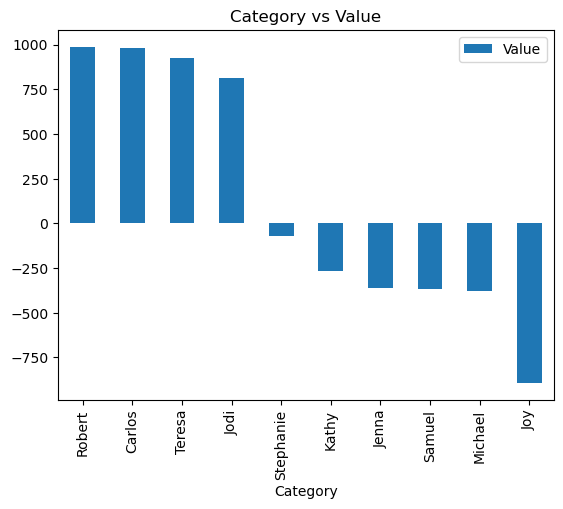

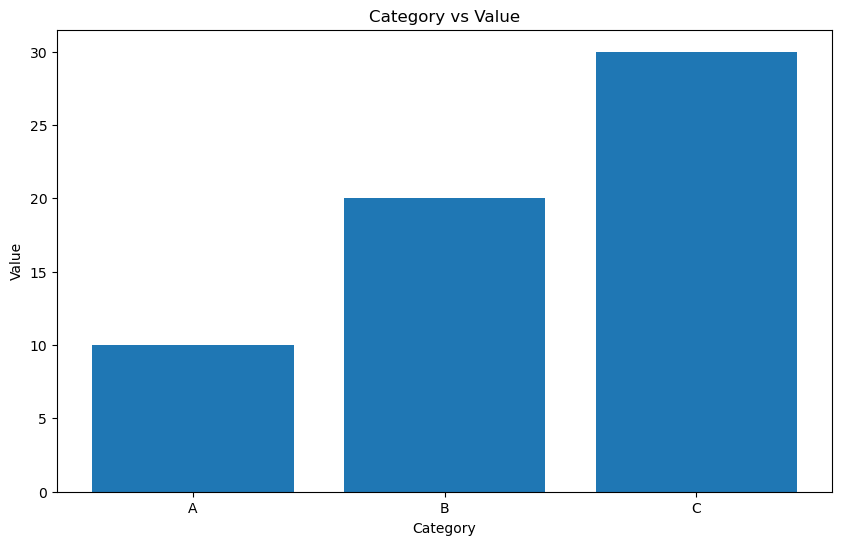

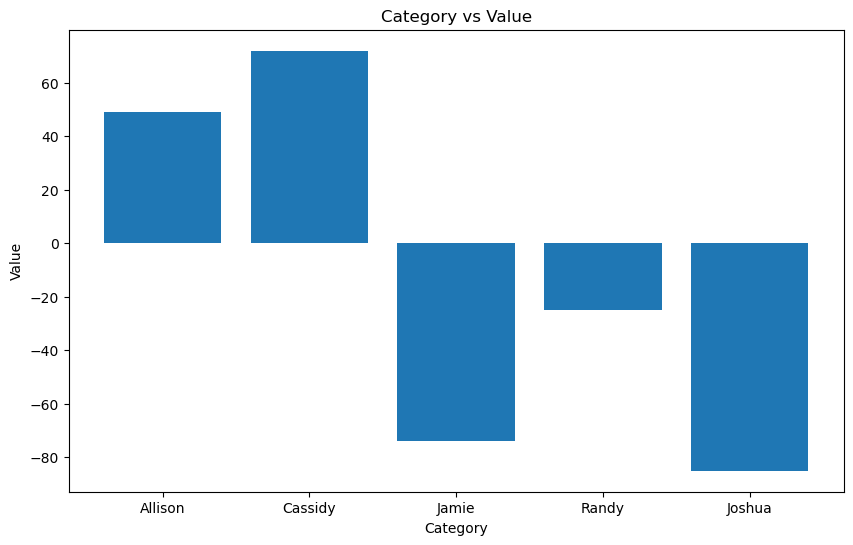

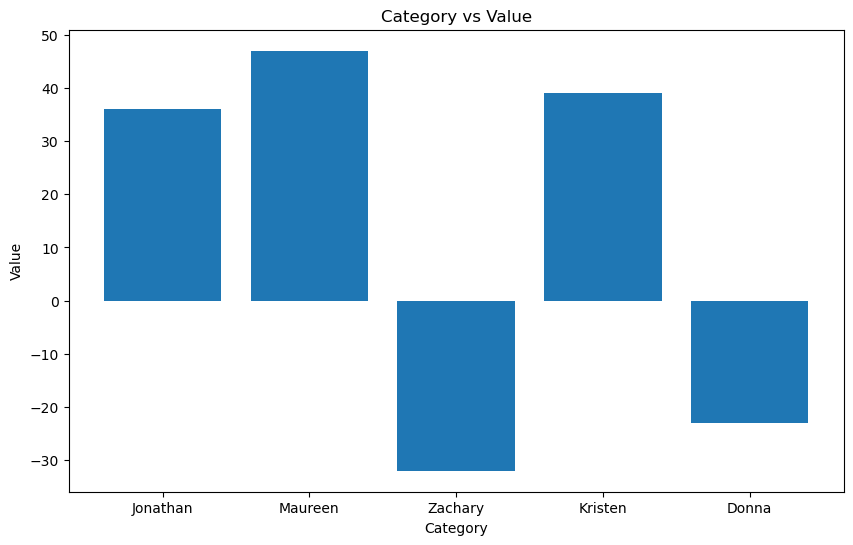

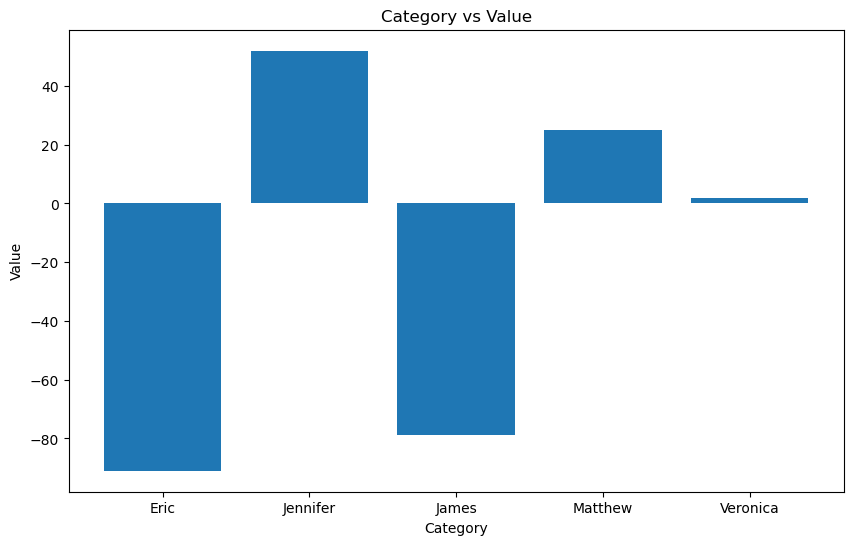

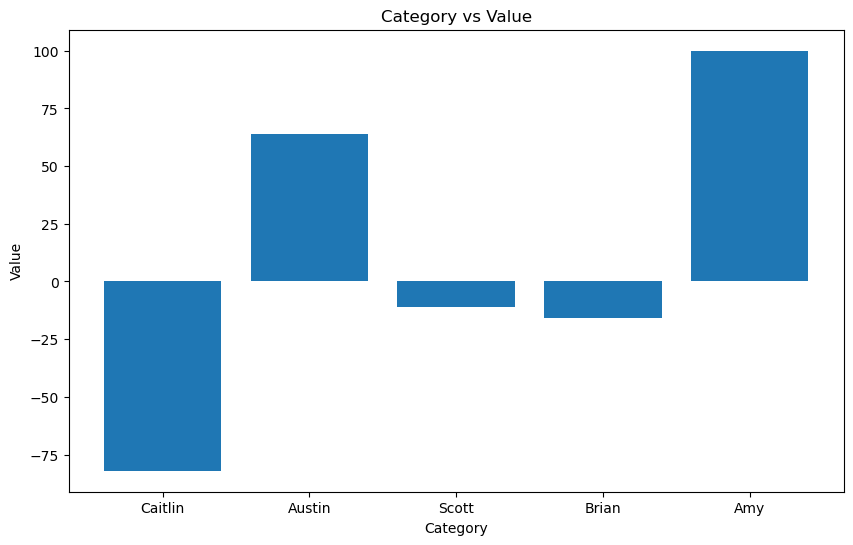

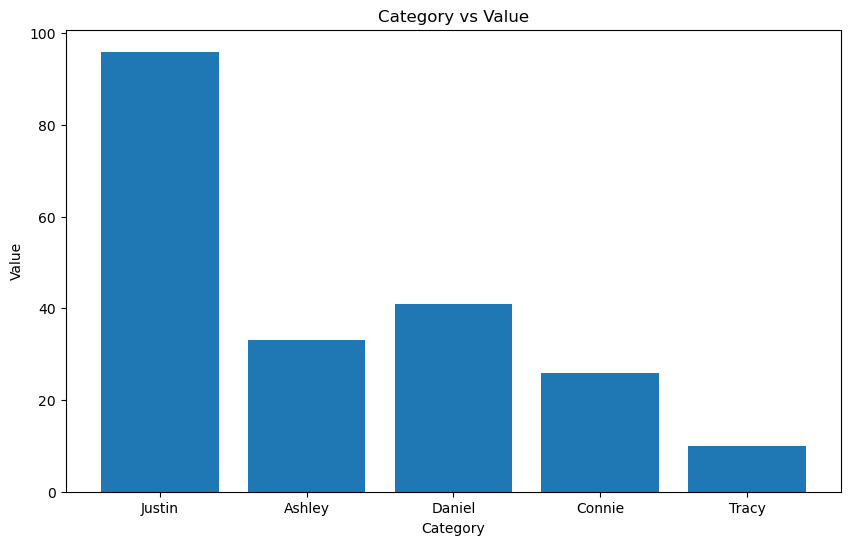

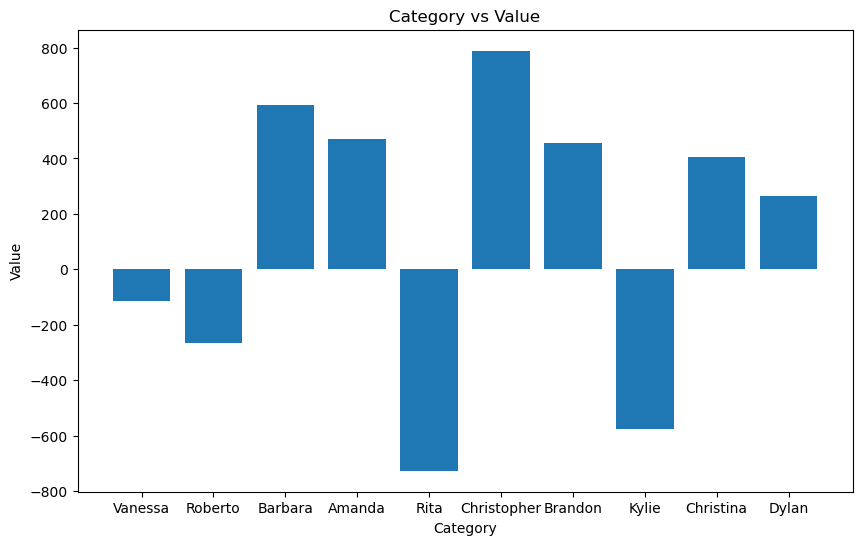

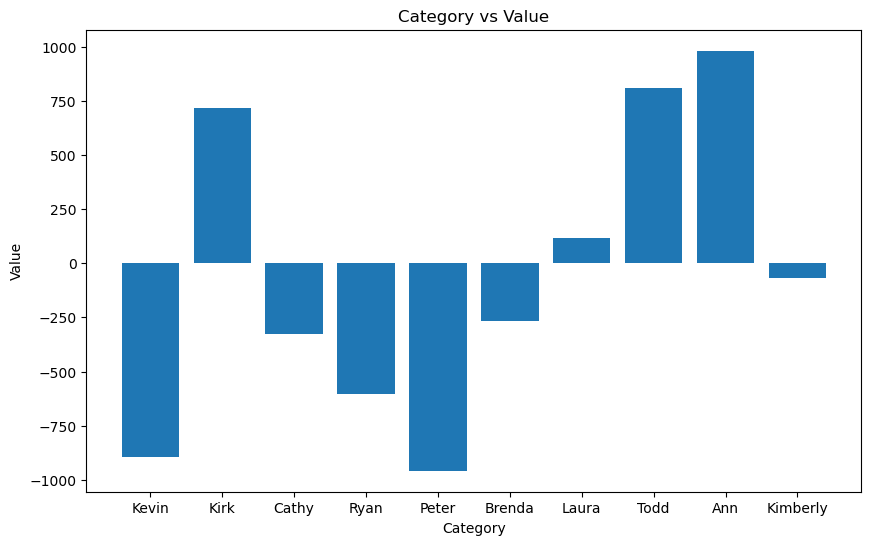

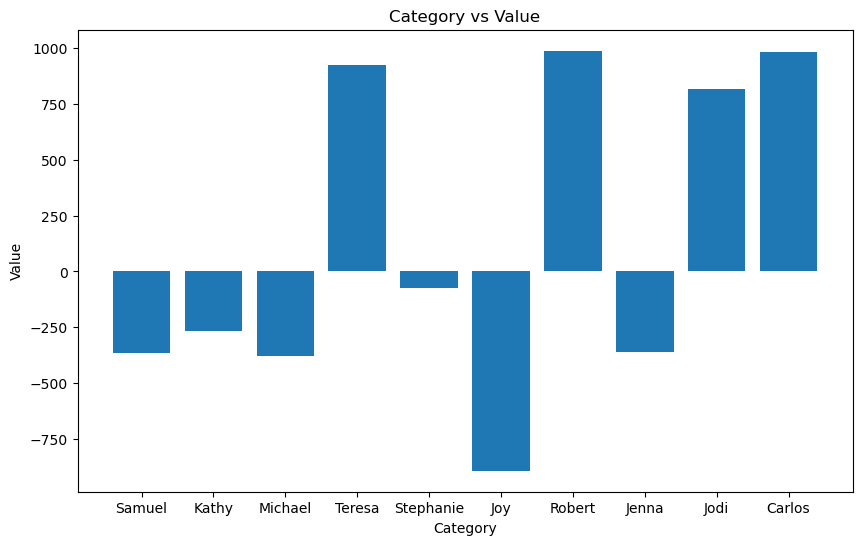

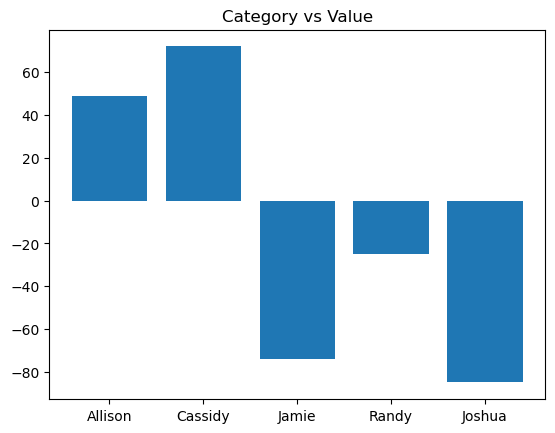

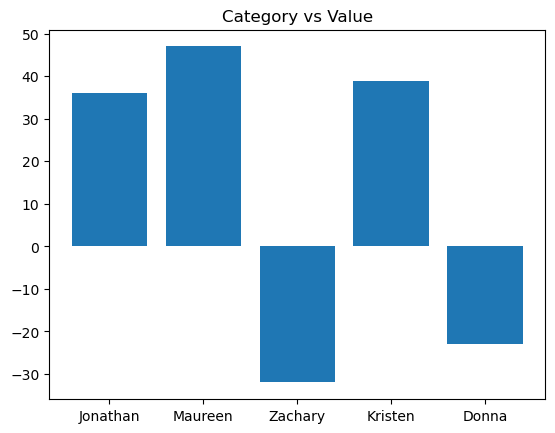

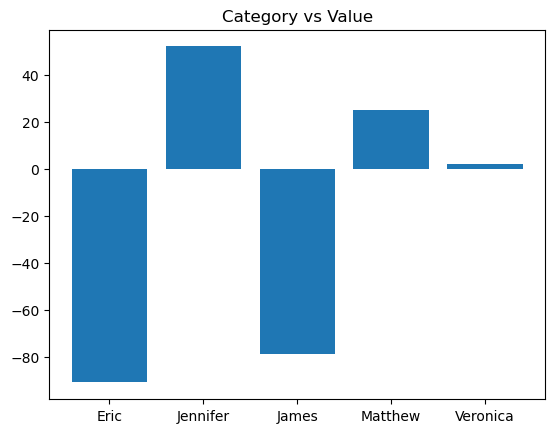

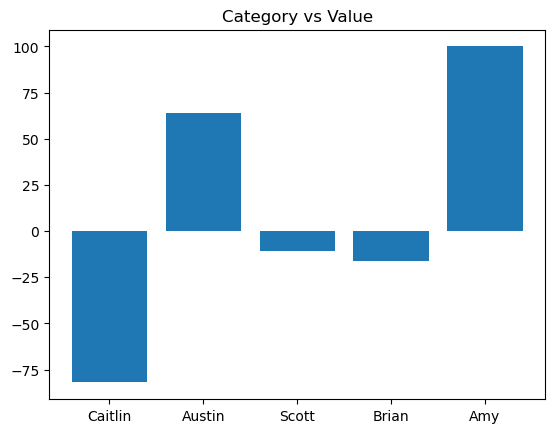

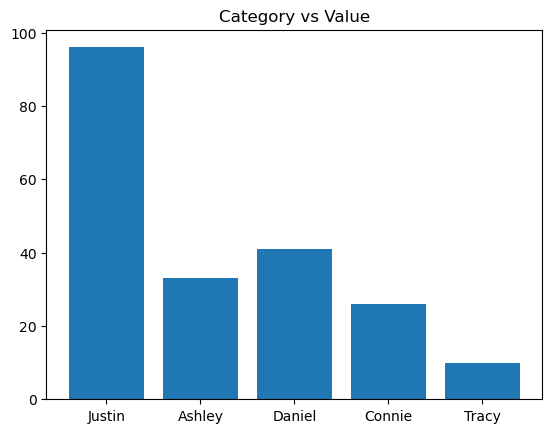

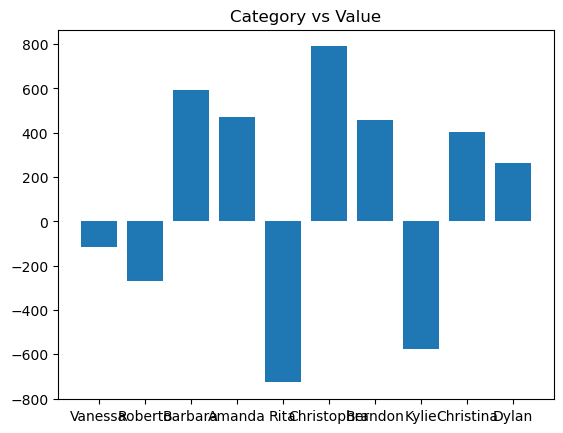

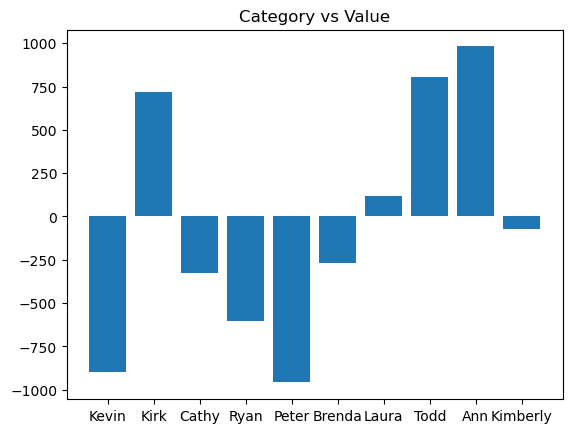

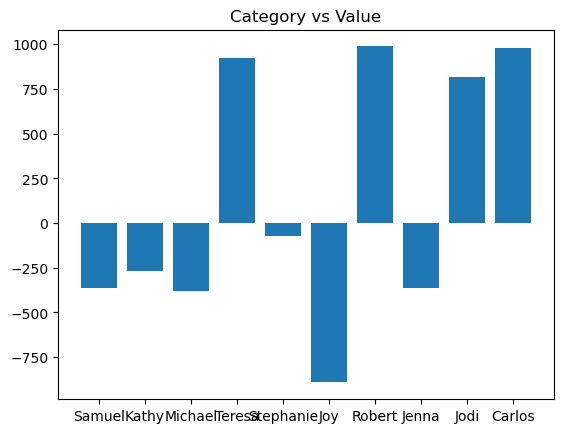

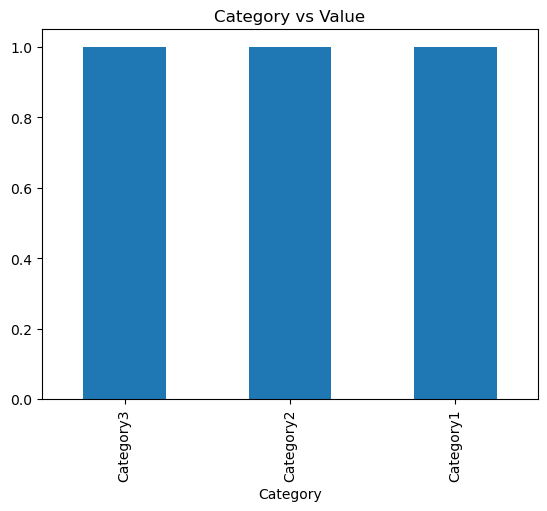

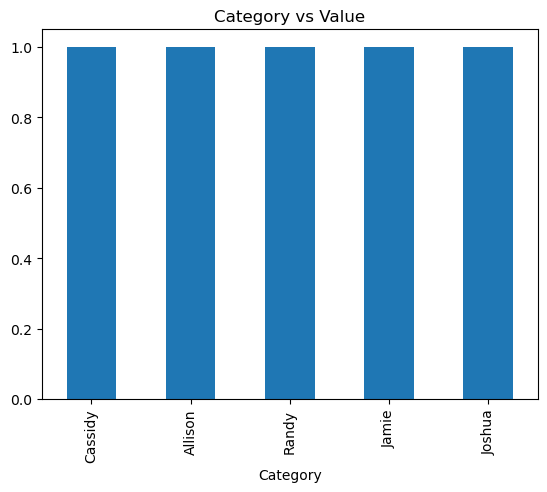

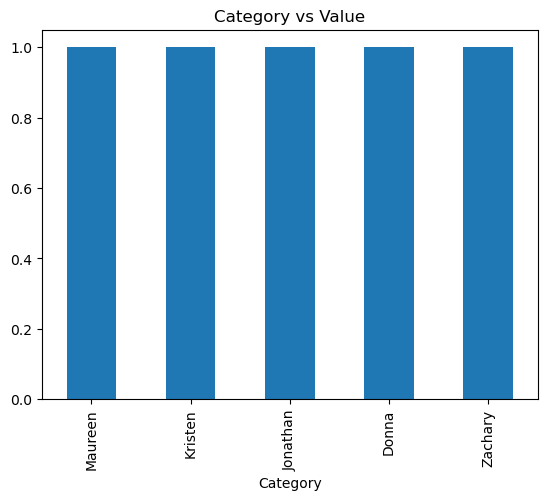

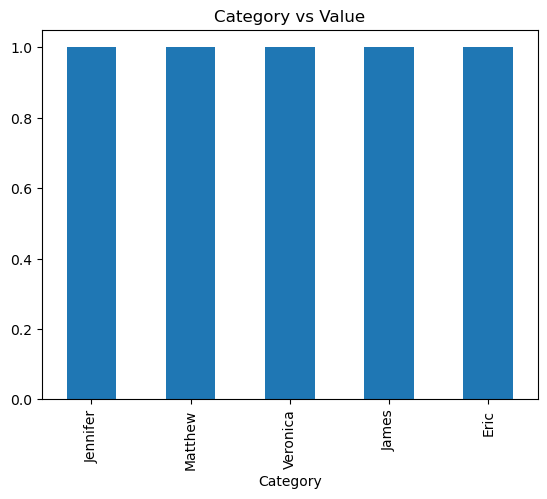

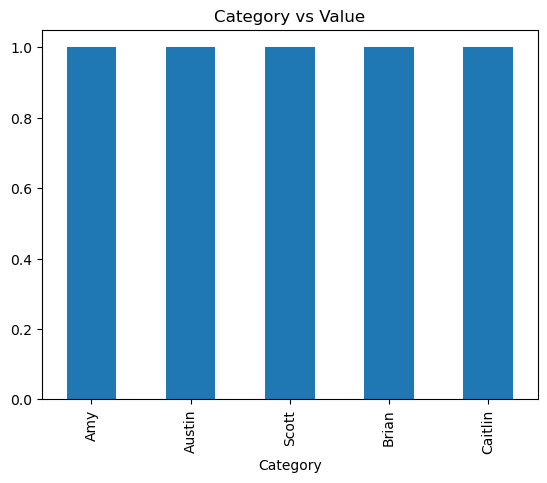

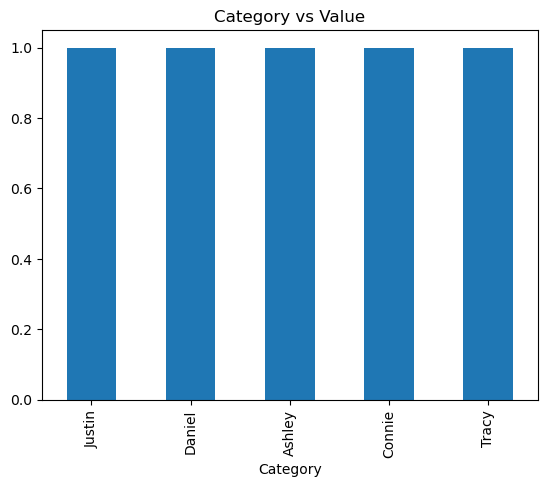

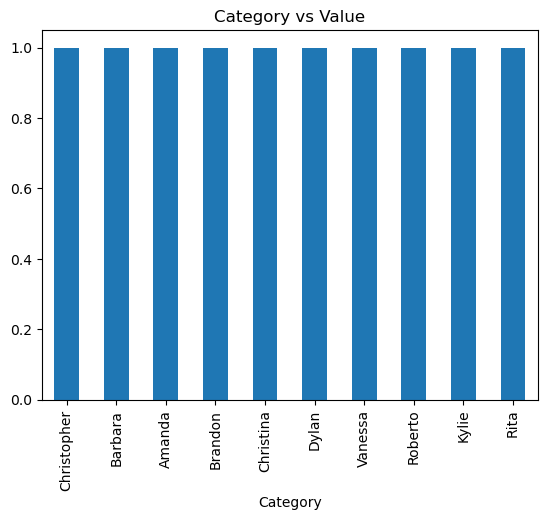

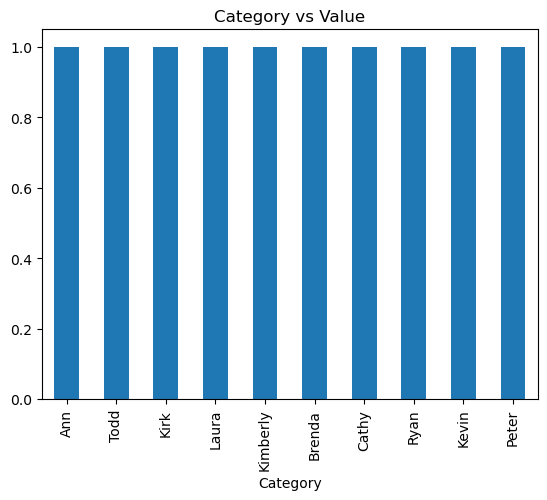

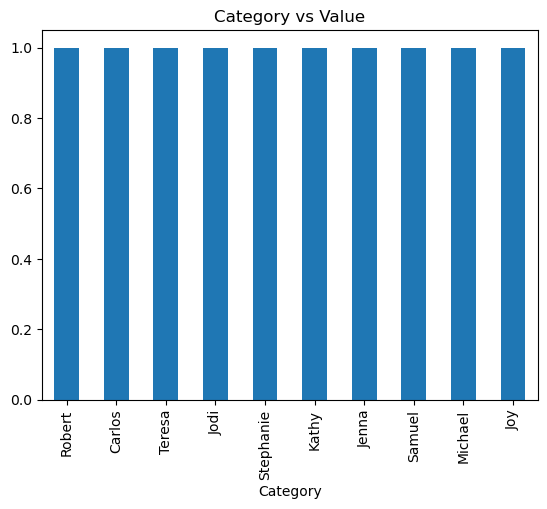

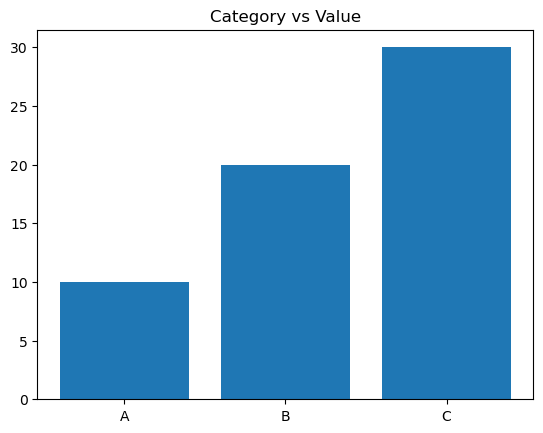

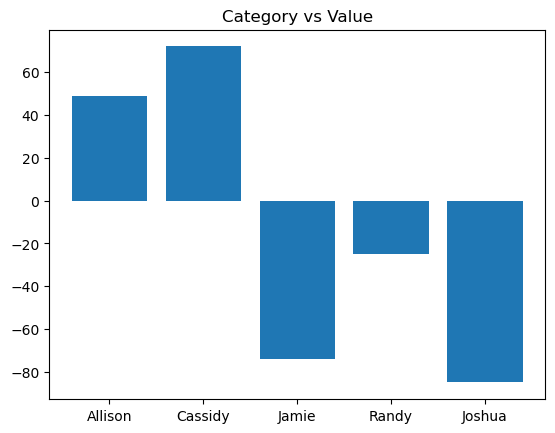

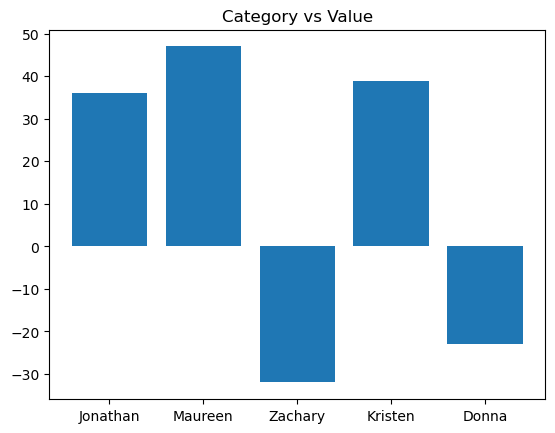

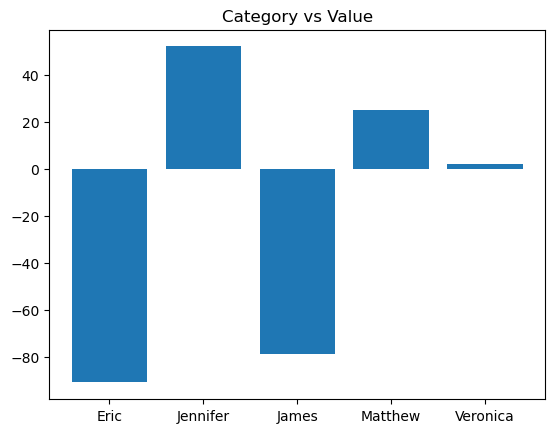

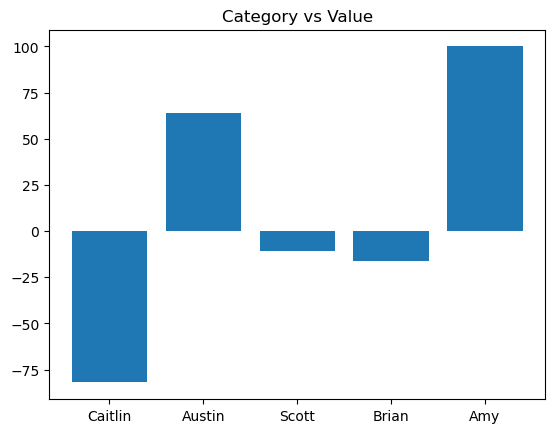

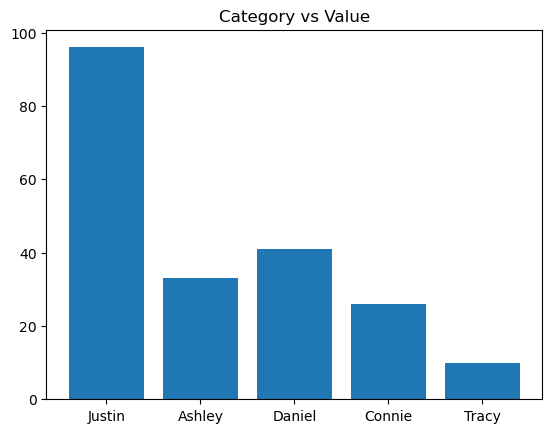

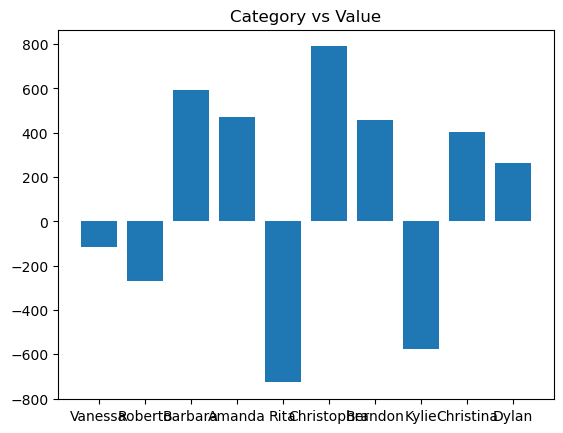

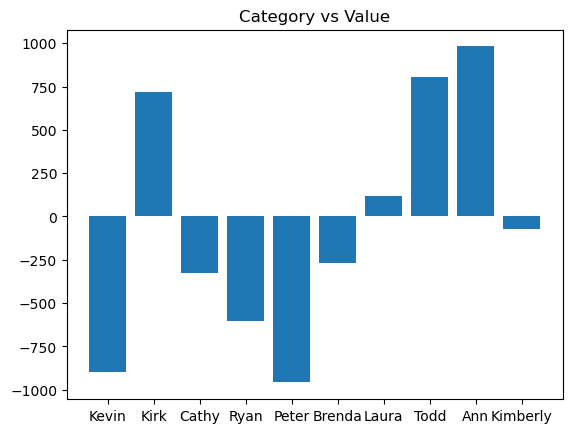

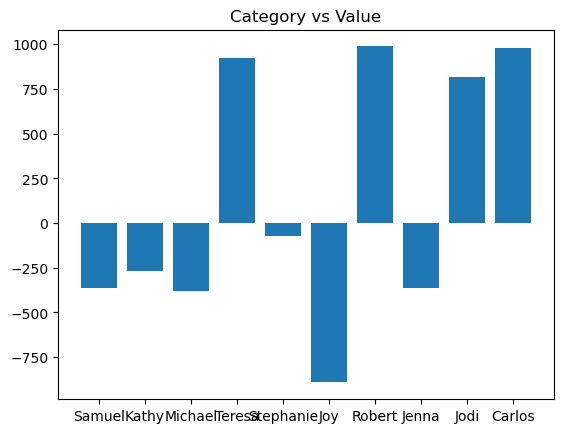

In [47]:
import os, json
from src.utils import validate_with_unittest

# Load datasets
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)  # original dataset with tests
with open(OUT_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)  # dataset with clones

# Index original dataset by id for quick lookup
data_by_id = {entry["id"]: entry for entry in data}

results = []

# Iterate over clones dataset
for i, clone_entry in enumerate(clone_data, 1):
    entry_id = clone_entry["id"]
    print(f"\nTesting Entry {i}/{len(clone_data)} | id={entry_id}")

    if entry_id not in data_by_id:
        print(f"  ⚠️ No matching entry found for {entry_id}, skipping.")
        continue

    # Get the corresponding original entry
    entry = data_by_id[entry_id]
    tests_list = entry.get("test", [])

    clones_with_results = []
    for k, clone in enumerate(clone_entry.get("clones", []), 1):
        try:
            code = clone["code"]

            # Run unit tests on the clone
            test_results = validate_with_unittest(code, tests_list)
            clone["test_results"] = test_results

            # Print summary
            passed = sum(1 for v in test_results.values() if v == "PASS")
            total = len(test_results)
            print(f"  Clone {k}: {passed}/{total} tests passed")

        except Exception as e:
            print(f"  ❌ Error testing clone {k}: {e}")
            clone["test_results"] = {}

        clones_with_results.append(clone)

    # Add clones to original entry
    entry["clones"] = clones_with_results
    results.append(entry)


with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Done. Saved dataset with test results to {OUT_PATH}")


## Calculating similarity scores

In [ ]:
import json
from collections import Counter
from nltk.util import ngrams
import numpy as np
from codebleu import calc_codebleu
from src.similarity import tokenize_code, is_trivial_ngram

#  CONFIG 
K = 500

#  Load dataset 
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

#  Build global ngram frequency (optional, if you need for filtering/trivial n-grams) 
all_ngrams = []
for entry in dataset:
    tokens = tokenize_code(entry["original_code"])
    for n in range(1, 5):
        all_ngrams.extend(list(ngrams(tokens, n)))
    for clone in entry.get("clones", []):
        tokens = tokenize_code(clone["code"])
        for n in range(1, 5):
            all_ngrams.extend(list(ngrams(tokens, n)))

freq = Counter(all_ngrams)
most_common_dict = {
    ngram: 1 for ngram, _ in freq.most_common(K) if not is_trivial_ngram(ngram)
}

# Compute CodeBLEU
labels, codebleu_scores = [], []

for entry in dataset:
    ref = entry["original_code"]
    for clone in entry.get("clones", []):
        hyp = clone["code"]
        labels.append(1)

        codebleu_score = calc_codebleu([ref], [hyp], lang="python")["codebleu"]
        codebleu_scores.append(codebleu_score)

        clone.setdefault("metrics", {})
        clone["metrics"].update({
            "codebleu": float(codebleu_score),
        })

# Compute averages
print(f"Avg CodeBLEU: {np.mean(codebleu_scores):.4f}")

# Save dataset
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(dataset, f, indent=2)

Avg CodeBLEU: 0.4943


In [ ]:
# import json
# from collections import Counter
# from nltk.util import ngrams
# import numpy as np
# from crystalbleu import corpus_bleu
# from codebleu import calc_codebleu
# from nltk.translate.bleu_score import SmoothingFunction
# from src.similarity import tokenize_code, is_trivial_ngram
# import fractions

# #  CONFIG 
# K = 500
# sm_func = SmoothingFunction(epsilon=0.0001).method1

# #  Patch Fraction for Python >=3.11 
# _OrigFraction_new = fractions.Fraction.__new__
# def fraction_new_patched(cls, *args, **kwargs):
#     kwargs.pop("_normalize", None)
#     return _OrigFraction_new(cls, *args, **kwargs)
# fractions.Fraction.__new__ = fraction_new_patched

# #  Load dataset 
# with open(OUT_PATH, "r", encoding="utf-8") as f:
#     dataset = json.load(f)

# #  Build global ngram frequency 
# all_ngrams = []
# for entry in dataset:
#     tokens = tokenize_code(entry["original_code"])
#     for n in range(1,5):
#         all_ngrams.extend(list(ngrams(tokens, n)))
#     for clone in entry.get("clones", []):
#         tokens = tokenize_code(clone["code"])
#         for n in range(1,5):
#             all_ngrams.extend(list(ngrams(tokens, n)))

# freq = Counter(all_ngrams)
# most_common_dict = {ngram:1 for ngram,_ in freq.most_common(K) if not is_trivial_ngram(ngram)}

# #  Compute BLEU / CrystalBLEU / CodeBLEU 
# labels, bleu_scores, crystal_scores, codebleu_scores = [], [], [], []

# for entry in dataset:
#     ref = tokenize_code(entry["original_code"])
#     for clone in entry.get("clones", []):
#         hyp = tokenize_code(clone["code"])
#         labels.append(1)

#         bleu = corpus_bleu([ref], [hyp], smoothing_function=sm_func)
#         crystal = corpus_bleu([ref], [hyp], smoothing_function=sm_func, ignoring=most_common_dict)
#         codebleu_score = calc_codebleu([entry["original_code"]], [clone["code"]], lang="python")["codebleu"]

#         bleu_scores.append(bleu)
#         crystal_scores.append(crystal)
#         codebleu_scores.append(codebleu_score)

#         clone.setdefault("metrics", {})
#         clone["metrics"].update({
#             "bleu": float(bleu),
#             "crystalbleu": float(crystal),
#             "codebleu": float(codebleu_score),
#         })

# #  Compute averages 
# print(f"Avg BLEU: {np.mean(bleu_scores):.4f}")
# print(f"Avg CrystalBLEU: {np.mean(crystal_scores):.4f}")
# print(f"Avg CodeBLEU: {np.mean(codebleu_scores):.4f}")

# #  Save dataset 
# with open(OUT_PATH, "w", encoding="utf-8") as f:
#     json.dump(dataset, f, indent=2)

# #  Restore original Fraction to avoid side effects 
# fractions.Fraction.__new__ = _OrigFraction_new

# print("✅ Finished scoring with BLEU, CrystalBLEU, and CodeBLEU.")


## Plotting

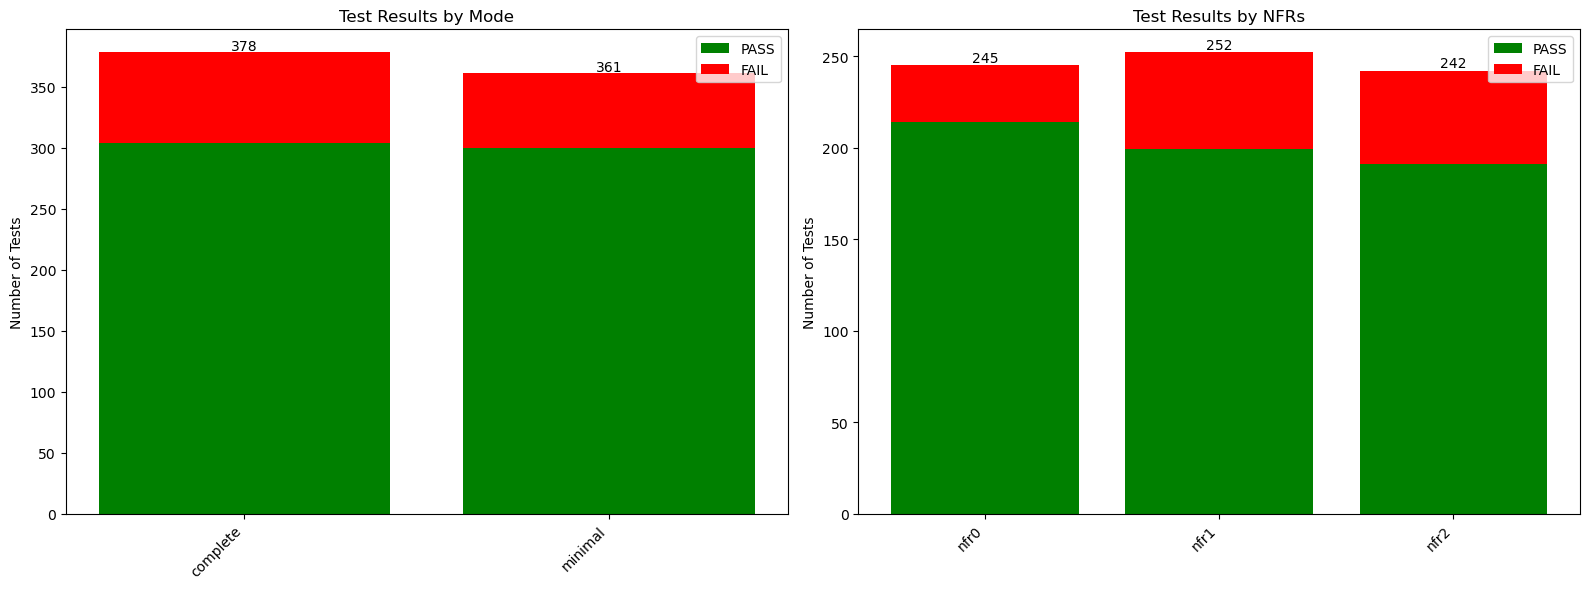

In [ ]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Initialize dictionaries for grouping
grouped_by_mode = {}
grouped_by_nfrs = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        mode = clone.get("mode", "unknown")
        nfrs = clone.get("nfrs", "unknown")  # assuming each clone has a "nfrs" field
        results = clone.get("test_results", {})

        # --- Group by mode ---
        if mode not in grouped_by_mode:
            grouped_by_mode[mode] = {"PASS": 0, "FAIL": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL"]:
                grouped_by_mode[mode][status] += 1

        # --- Group by NFR ---
        if nfrs not in grouped_by_nfrs:
            grouped_by_nfrs[nfrs] = {"PASS": 0, "FAIL": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL"]:
                grouped_by_nfrs[nfrs][status] += 1

# Function to prepare data for plotting
def prepare_data(grouped_dict):
    filters = list(grouped_dict.keys())
    passes = [grouped_dict[h]["PASS"] for h in filters]
    fails  = [grouped_dict[h]["FAIL"] for h in filters]
    return filters, passes, fails

# Prepare data
filters_mode, passes_mode, fails_mode = prepare_data(grouped_by_mode)
filters_nfrs, passes_nfrs, fails_nfrs = prepare_data(grouped_by_nfrs)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot Mode ---
x_mode = range(len(filters_mode))
axes[0].bar(x_mode, passes_mode, color="green", label="PASS")
axes[0].bar(x_mode, fails_mode, bottom=passes_mode, color="red", label="FAIL")
axes[0].set_xticks(x_mode)
axes[0].set_xticklabels(filters_mode, rotation=45, ha="right")
axes[0].set_ylabel("Number of Tests")
axes[0].set_title("Test Results by Mode")
axes[0].legend()
for i, (p, f) in enumerate(zip(passes_mode, fails_mode)):
    total = p + f
    axes[0].text(i, total + 2, str(total), ha="center", fontsize=10)

# --- Plot NFRs ---
x_nfrs = range(len(filters_nfrs))
axes[1].bar(x_nfrs, passes_nfrs, color="green", label="PASS")
axes[1].bar(x_nfrs, fails_nfrs, bottom=passes_nfrs, color="red", label="FAIL")
axes[1].set_xticks(x_nfrs)
axes[1].set_xticklabels(filters_nfrs, rotation=45, ha="right")
axes[1].set_ylabel("Number of Tests")
axes[1].set_title("Test Results by NFRs")
axes[1].legend()
for i, (p, f) in enumerate(zip(passes_nfrs, fails_nfrs)):
    total = p + f
    axes[1].text(i, total + 2, str(total), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

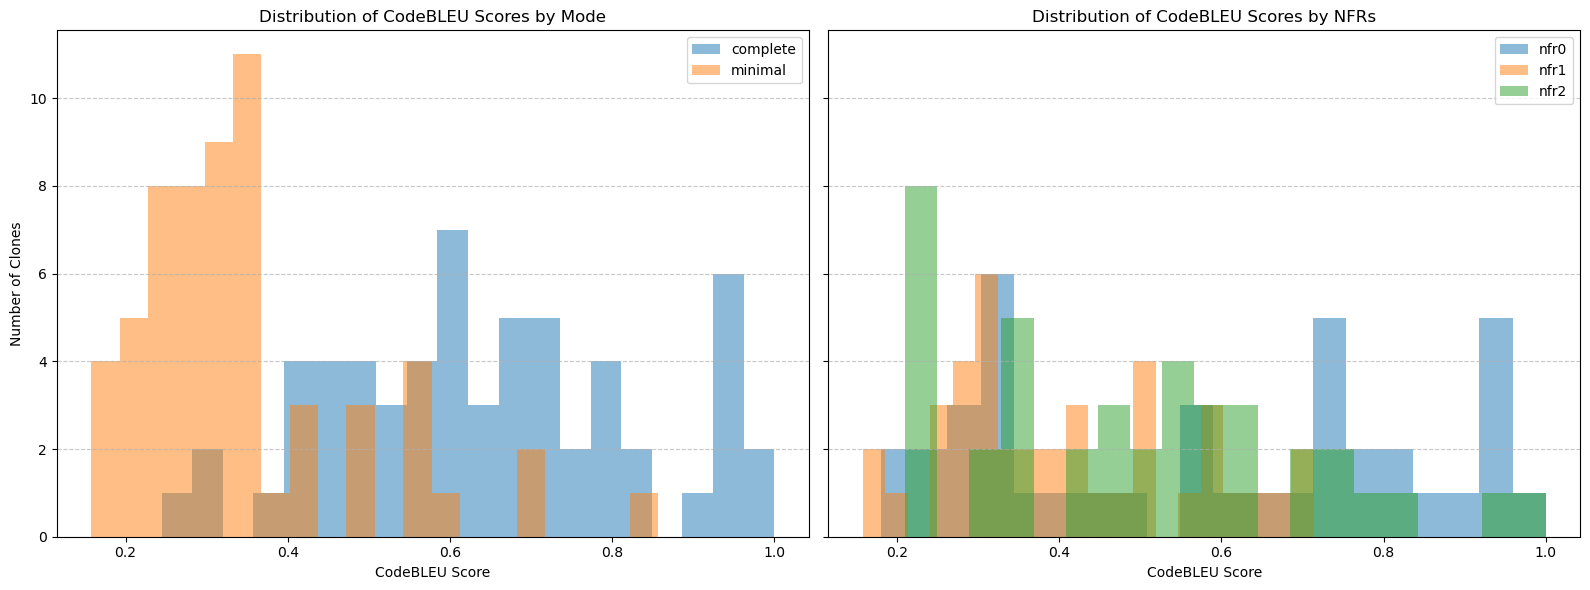

C:\Users\lamp6\AppData\Local\Temp\ipykernel_11836\4273346863.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_11836\4273346863.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


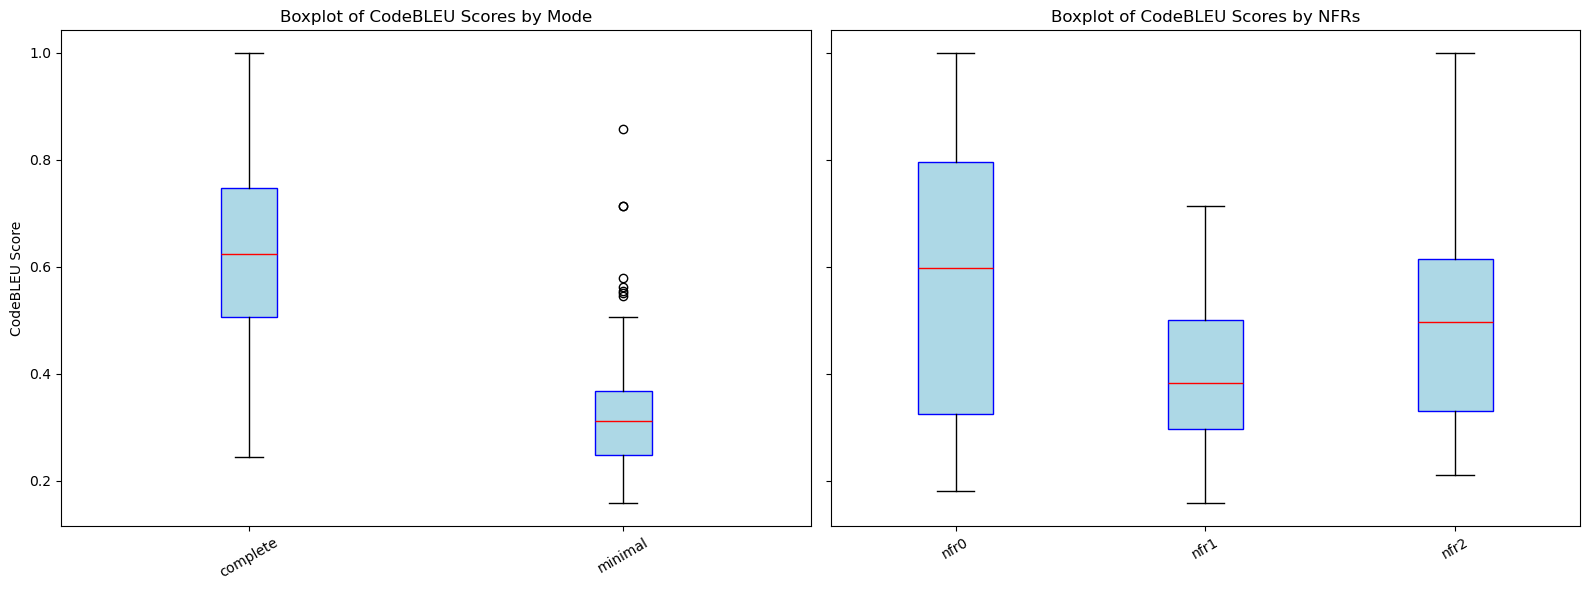

In [ ]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

#  Collect CodeBLEU scores per mode and per nfrs 
scores_by_mode = {}
scores_by_nfrs = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        mode = clone.get("mode", "unknown")
        nfrs = clone.get("nfrs", "unknown")  # assuming clone has "nfrs" field
        score = clone.get("metrics", {}).get("codebleu")
        if score is not None:
            scores_by_mode.setdefault(mode, []).append(score)
            scores_by_nfrs.setdefault(nfrs, []).append(score)

#  Histograms side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Histogram by mode
for mode, scores in scores_by_mode.items():
    axes[0].hist(scores, bins=20, alpha=0.5, label=mode)
axes[0].set_xlabel("CodeBLEU Score")
axes[0].set_ylabel("Number of Clones")
axes[0].set_title("Distribution of CodeBLEU Scores by Mode")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Histogram by NFRs
for nfrs, scores in scores_by_nfrs.items():
    axes[1].hist(scores, bins=20, alpha=0.5, label=nfrs)
axes[1].set_xlabel("CodeBLEU Score")
axes[1].set_title("Distribution of CodeBLEU Scores by NFRs")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#  Boxplots side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Boxplot by mode
labels_mode = list(scores_by_mode.keys())
data_mode = [scores_by_mode[m] for m in labels_mode]
axes[0].boxplot(
    data_mode, vert=True, patch_artist=True,
    labels=labels_mode,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red")
)
axes[0].set_ylabel("CodeBLEU Score")
axes[0].set_title("Boxplot of CodeBLEU Scores by Mode")
axes[0].tick_params(axis="x", rotation=30)

# Boxplot by NFRs
labels_nfrs = list(scores_by_nfrs.keys())
data_nfrs = [scores_by_nfrs[n] for n in labels_nfrs]
axes[1].boxplot(
    data_nfrs, vert=True, patch_artist=True,
    labels=labels_nfrs,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red")
)
axes[1].set_title("Boxplot of CodeBLEU Scores by NFRs")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

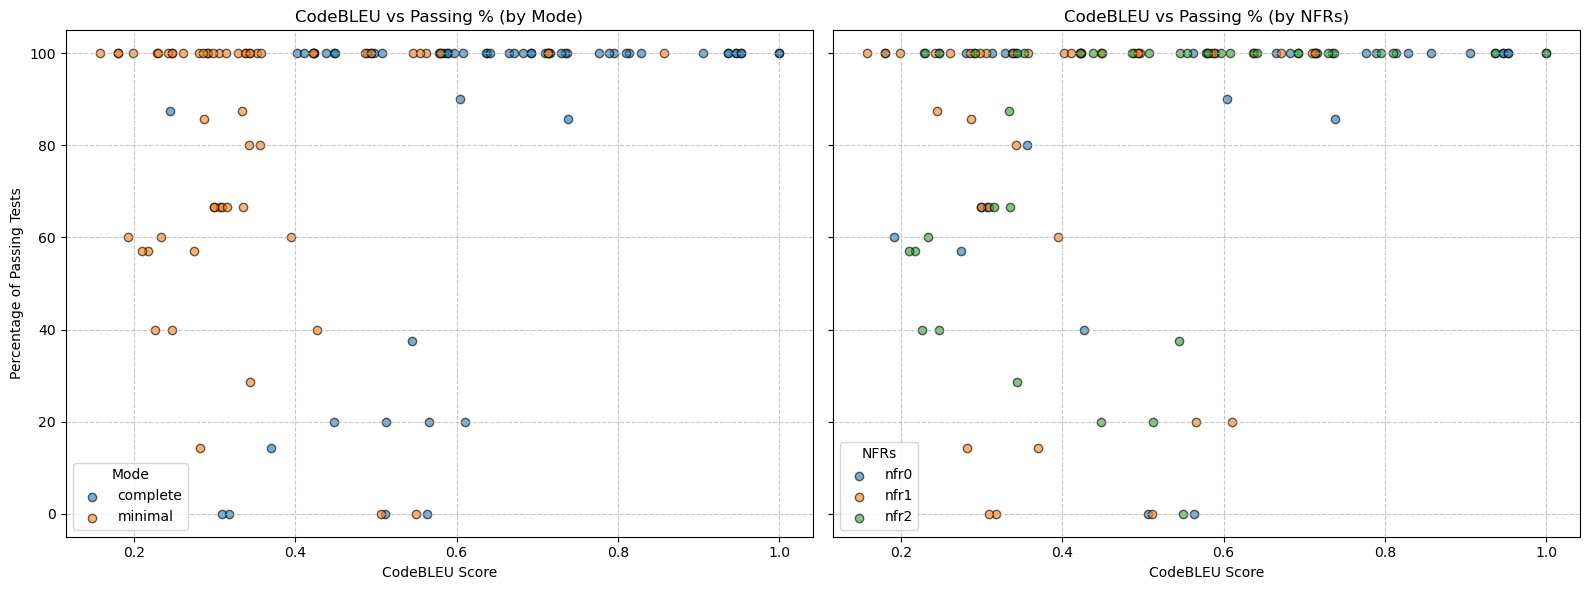

In [ ]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

#  Collect per-clone metrics, grouped by mode and nfrs 
grouped_by_mode = {}
grouped_by_nfrs = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        total_tests = len(results)
        if total_tests == 0:
            continue

        passed_tests = sum(1 for status in results.values() if status.upper() == "PASS")
        passing_percentage = 100 * passed_tests / total_tests
        score = clone.get("metrics", {}).get("codebleu", 0)

        mode = clone.get("mode", "unknown")
        nfrs = clone.get("nfrs", "unknown")  # assuming clone has "nfrs" field

        # --- group by mode ---
        if mode not in grouped_by_mode:
            grouped_by_mode[mode] = {"codebleu": [], "passing": []}
        grouped_by_mode[mode]["codebleu"].append(score)
        grouped_by_mode[mode]["passing"].append(passing_percentage)

        # --- group by nfrs ---
        if nfrs not in grouped_by_nfrs:
            grouped_by_nfrs[nfrs] = {"codebleu": [], "passing": []}
        grouped_by_nfrs[nfrs]["codebleu"].append(score)
        grouped_by_nfrs[nfrs]["passing"].append(passing_percentage)

#  Scatter plots side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Scatter by mode
for mode, data in grouped_by_mode.items():
    axes[0].scatter(
        data["codebleu"],
        data["passing"],
        alpha=0.6,
        edgecolor="black",
        label=mode
    )
axes[0].set_xlabel("CodeBLEU Score")
axes[0].set_ylabel("Percentage of Passing Tests")
axes[0].set_title("CodeBLEU vs Passing % (by Mode)")
axes[0].legend(title="Mode")
axes[0].grid(linestyle="--", alpha=0.7)

# Scatter by NFRs
for nfrs, data in grouped_by_nfrs.items():
    axes[1].scatter(
        data["codebleu"],
        data["passing"],
        alpha=0.6,
        edgecolor="black",
        label=nfrs
    )
axes[1].set_xlabel("CodeBLEU Score")
axes[1].set_title("CodeBLEU vs Passing % (by NFRs)")
axes[1].legend(title="NFRs")
axes[1].grid(linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


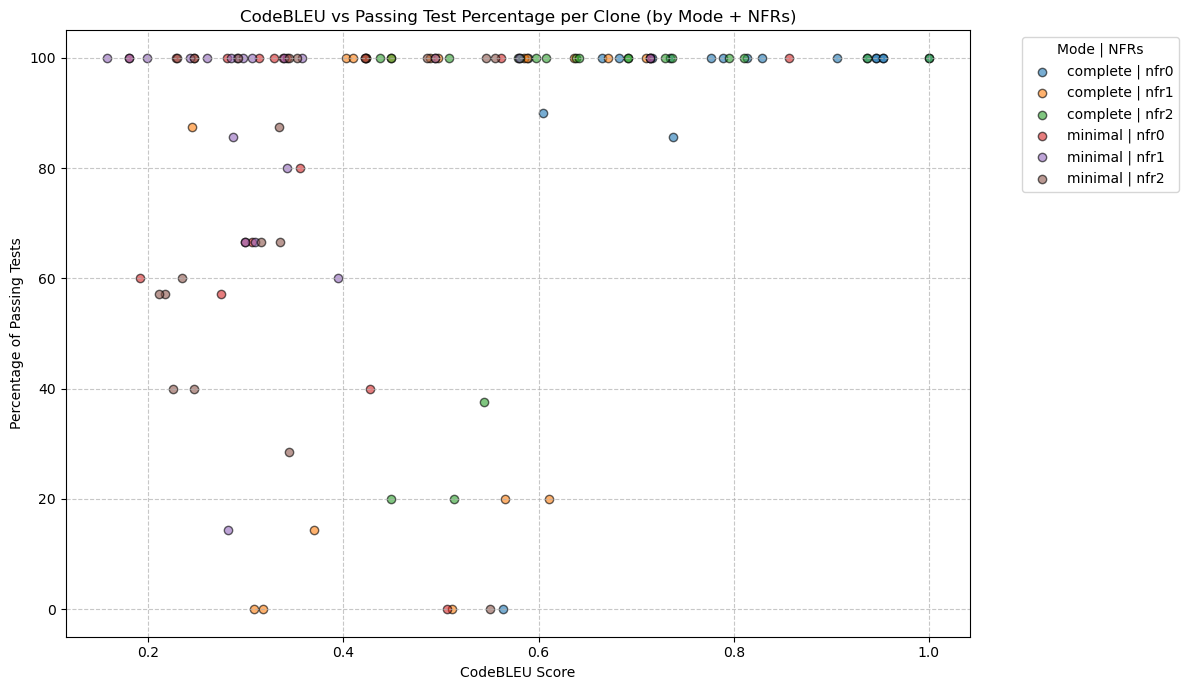

In [ ]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Collect per-clone metrics, grouped by mode+nfrs
grouped = {}  # { "mode | nfrs": {"codebleu": [], "passing": []} }
for entry in dataset:
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        total_tests = len(results)
        if total_tests == 0:
            continue
        passed_tests = sum(1 for status in results.values() if status.upper() == "PASS")
        passing_percentage = 100 * passed_tests / total_tests
        score = clone.get("metrics", {}).get("codebleu", 0)

        mode = clone.get("mode", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        key = f"{mode} | {nfrs}"

        if key not in grouped:
            grouped[key] = {"codebleu": [], "passing": []}
        grouped[key]["codebleu"].append(score)
        grouped[key]["passing"].append(passing_percentage)

# Scatter plot
plt.figure(figsize=(12, 7))
for label, data in grouped.items():
    plt.scatter(
        data["codebleu"],
        data["passing"],
        alpha=0.6,
        edgecolor="black",
        label=label
    )
plt.xlabel("CodeBLEU Score")
plt.ylabel("Percentage of Passing Tests")
plt.title("CodeBLEU vs Passing Test Percentage per Clone (by Mode + NFRs)")
plt.legend(title="Mode | NFRs", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()